# 📊 TOBIG'S 6주차 과제 — 데이터 시각화

세션에서 다룬 내용(*Fundamentals of Data Visualization*, Claus O. Wilke)을 직접 코드로 확인해 보는 과제입니다.

### 진행 방법
- 라이브러리는 **plotnine**을 사용합니다. R의 **ggplot2** 문법을 파이썬으로 옮긴 라이브러리라서 `ggplot(데이터, aes(...)) + geom_*()` 구조가 똑같습니다.
- 코드의 `____` 부분을 채워 셀을 실행하세요.
- 🔧 **고치기** 문제는 주어진 *나쁜 차트*를 세션 내용에 맞게 고치는 문제입니다.
- 📝 표시가 있는 문제는 **✍️ 답:** 칸에 2~3문장으로 답을 작성하세요.
- Colab의 한글 폰트 문제를 피하기 위해 **그래프 안의 라벨은 영어로** 작성합니다.

### 목차
1. 시각적 속성과 스케일
2. 위치 스케일 (선형 / 로그)
3. 색상 스케일 (정성적 / 강조 / 순차적 / 발산형)
4. 수량 데이터 (막대, 묶은·누적 막대, 점 도표, 순서형 범주)
5. 분포 데이터 (히스토그램, 밀도 도표, 여러 분포 비교)
6. 종합 문제

## 0. 준비

In [1]:
# Colab에는 plotnine이 기본 설치되어 있습니다. 없다는 에러가 나면 아래 줄의 주석을 풀고 실행하세요.
# !pip install -q plotnine

import numpy as np
import pandas as pd
from plotnine import *
from plotnine.data import mtcars, mpg, midwest, txhousing, faithful, penguins

# 세션에서 소개한 Okabe-Ito 정성적 팔레트 (색각 이상이 있어도 구분하기 쉬운 팔레트)
OKABE_ITO = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]

theme_set(theme_minimal() + theme(figure_size=(7, 4.5)))

## 1. 시각적 속성과 스케일

세션에서 **시각적 속성 = 값을 정량화 → 그래픽으로 표현**하는 것이고, **스케일**은 값과 시각적 속성을 연결하는 방식이라고 배웠습니다.
슬라이드 7의 자동차 산점도는 `mtcars` 데이터로 그린 그래프이며, **5개의 스케일**을 사용합니다.

### 문제 1-1 (빈칸)
`mtcars`로 슬라이드 7의 그래프를 재현하세요.

| 변수 | 의미 | 시각적 속성 |
|---|---|---|
| `disp` | 배기량 | x 위치 |
| `mpg` | 연비 | y 위치 |
| `hp` | 마력 | 색상 |
| `wt` | 무게 | 크기 |
| `cyl` | 실린더 수 | 모양 |

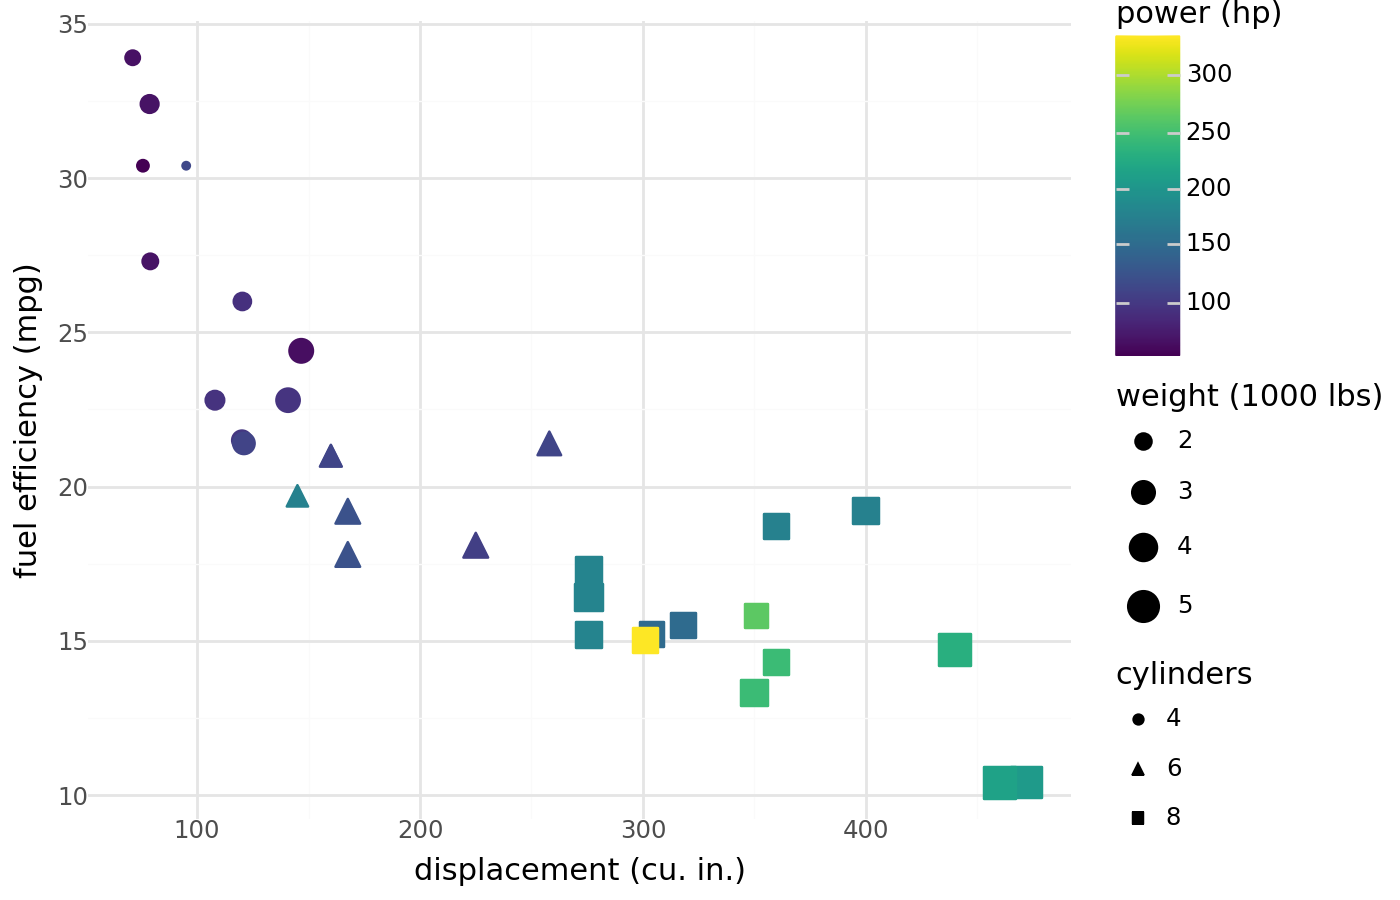

In [2]:
(
    ggplot(mtcars, aes(x="disp", y="mpg",
                       color="hp",          # TODO: 마력
                       size="wt",           # TODO: 무게
                       shape="factor(cyl)"))         # TODO: 실린더 수 (힌트: 범주형으로 바꿔야 합니다)
    + geom_point()
    + scale_color_cmap("viridis")
    + labs(x="displacement (cu. in.)", y="fuel efficiency (mpg)",
           color="power (hp)", size="weight (1000 lbs)", shape="cylinders")
)

### 문제 1-2 📝
`shape`에 `"cyl"` 대신 `"factor(cyl)"`을 넣어야 하는 이유는 무엇일까요? **모양**이라는 시각적 속성이 표현할 수 있는 데이터 종류와 연결해서 설명하세요.

**✍️ 답:** shape는 범주형, 명목형 데이터를 구분하기 위한 시각적 속성입니다. 연속형 수치 데이터인 cyl을 그대로 사용할 경우 모양 속성과 스케일 불일치가 발생하므로, factor()을 통해 범주형 데이터로 변환하여 명확한 그룹 간 구분을 형성해야합니다.

## 2. 위치 스케일 — 로그 스케일

슬라이드 13에서는 텍사스 카운티 인구를 **중간값으로 나눈 비율**로 그렸습니다.
선형 스케일에서는 몇몇 대도시 때문에 나머지 카운티가 바닥에 깔려 보이지 않았고, 로그 스케일을 쓰자 전체 구조가 드러났습니다.

여기서는 미국 중서부 5개 주, 437개 카운티 데이터인 `midwest`로 같은 분석을 해봅니다.

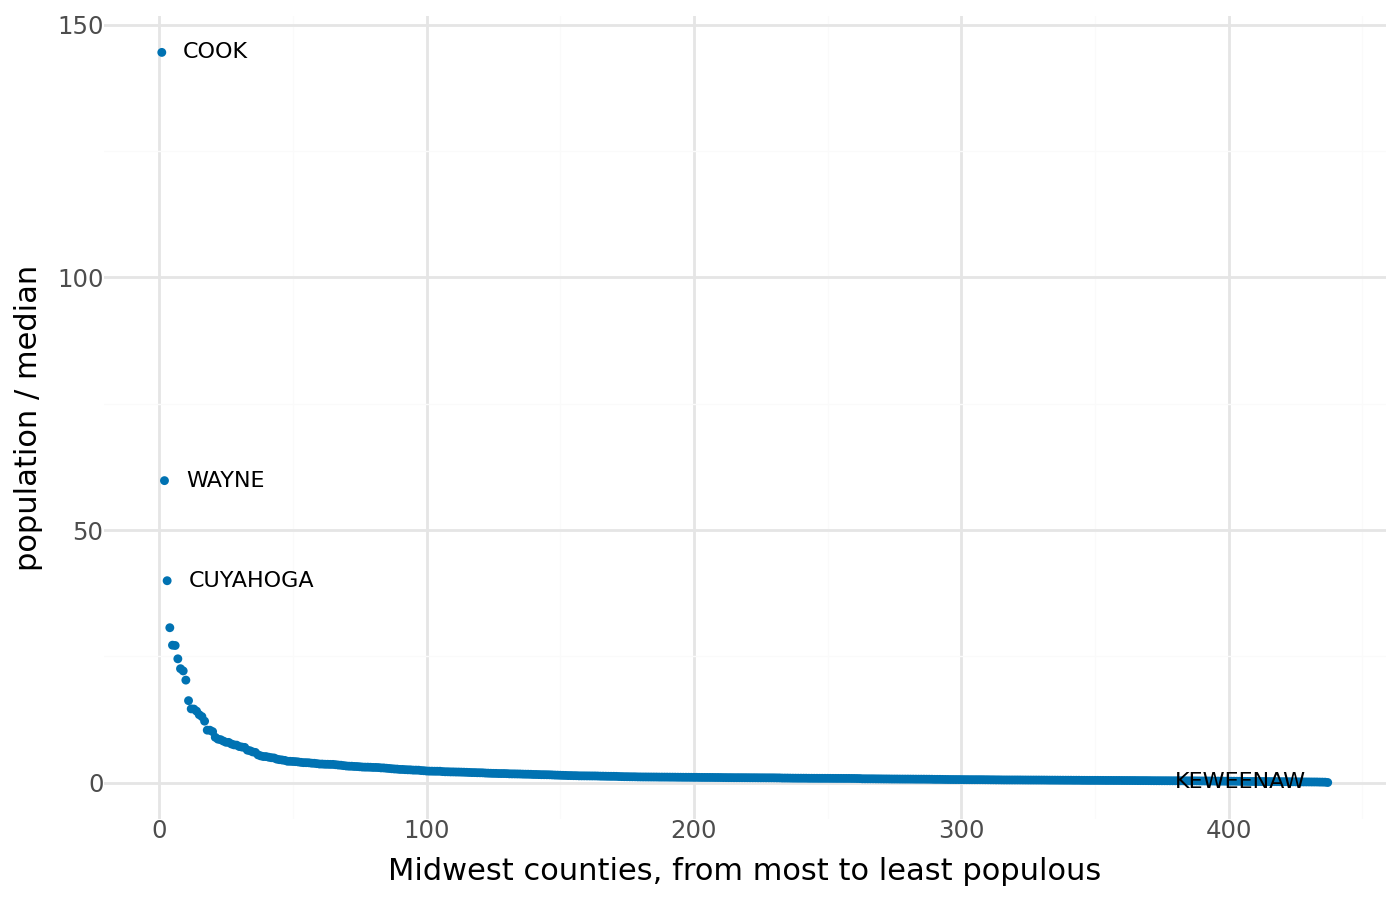

In [3]:
# 인구를 중간값으로 나눈 비율, 인구가 많은 순으로 순위 매기기
county = midwest[["county", "state", "poptotal"]].copy()
county["ratio"] = county["poptotal"] / county["poptotal"].median()
county = county.sort_values("ratio", ascending=False).reset_index(drop=True)
county["rank"] = np.arange(1, len(county) + 1)

# 라벨을 붙일 카운티: 상위 3개(점 오른쪽에 표시) + 최하위 1개(점 왼쪽에 표시)
p_linear = (
    ggplot(county, aes(x="rank", y="ratio"))
    + geom_point(size=0.8, color="#0072B2")
    + geom_text(aes(label="county"), data=county.head(3), ha="left", nudge_x=8, size=8)
    + geom_text(aes(label="county"), data=county.tail(1), ha="right", nudge_x=-8, size=8)
    + labs(x="Midwest counties, from most to least populous", y="population / median")
)
p_linear

### 문제 2-1 (빈칸)
위 그래프는 선형 스케일이라 대부분의 카운티가 0 근처에 몰려 있습니다. y축을 **로그 스케일**로 바꾸고, 중간값(비율 = 1)에 점선 기준선을 추가하세요.

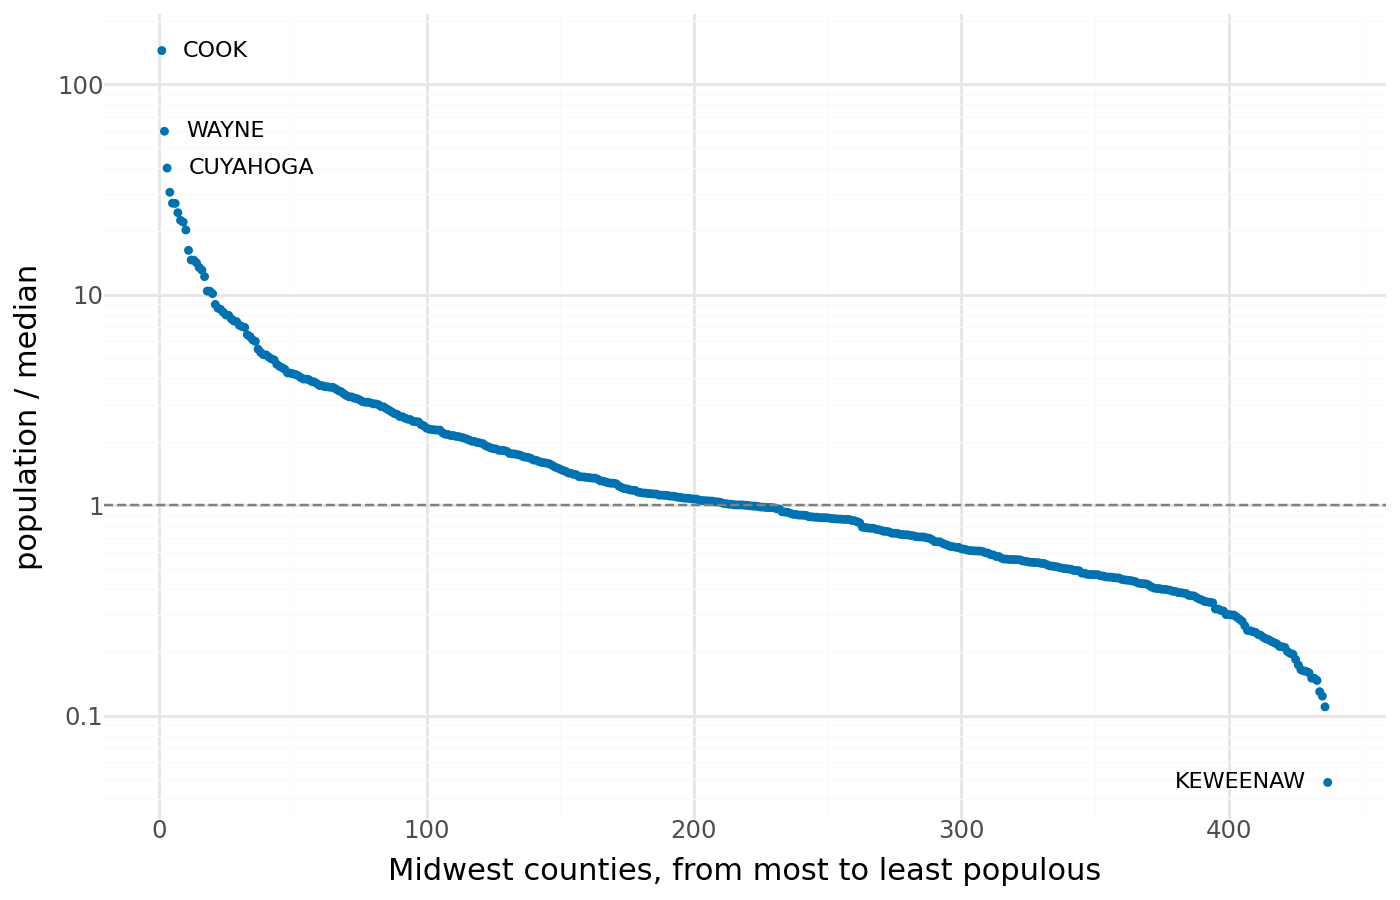

In [4]:
(
    p_linear
    + scale_y_log10()                                                    # TODO: y축 로그 스케일
    + geom_hline(yintercept=1, linetype="dashed", color="gray")   # TODO: 중간값 위치
)

### 문제 2-2 🔧 고치기
슬라이드 11의 *wrong* 사례처럼, 아래 그래프는 **데이터와 축 제목이 맞지 않습니다.**
무엇이 잘못됐는지 찾고, 원본 데이터를 로그 스케일로 올바르게 그리도록 고치세요.

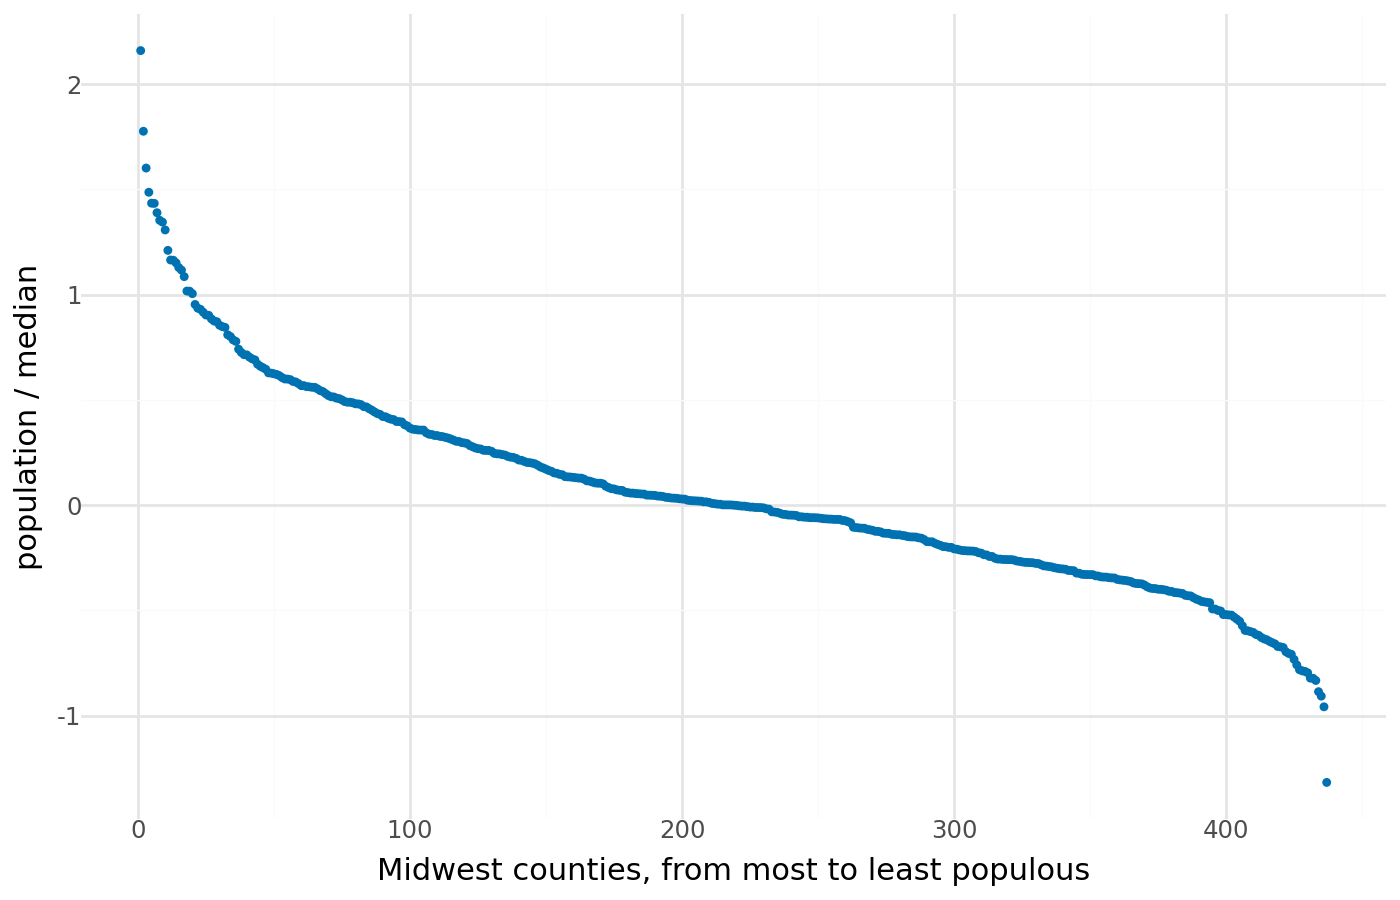

In [5]:
# ❌ 잘못된 그래프 (그대로 두세요)
county["log_ratio"] = np.log10(county["ratio"])

(
    ggplot(county, aes(x="rank", y="log_ratio"))
    + geom_point(size=0.8, color="#0072B2")
    + labs(x="Midwest counties, from most to least populous", y="population / median")
)

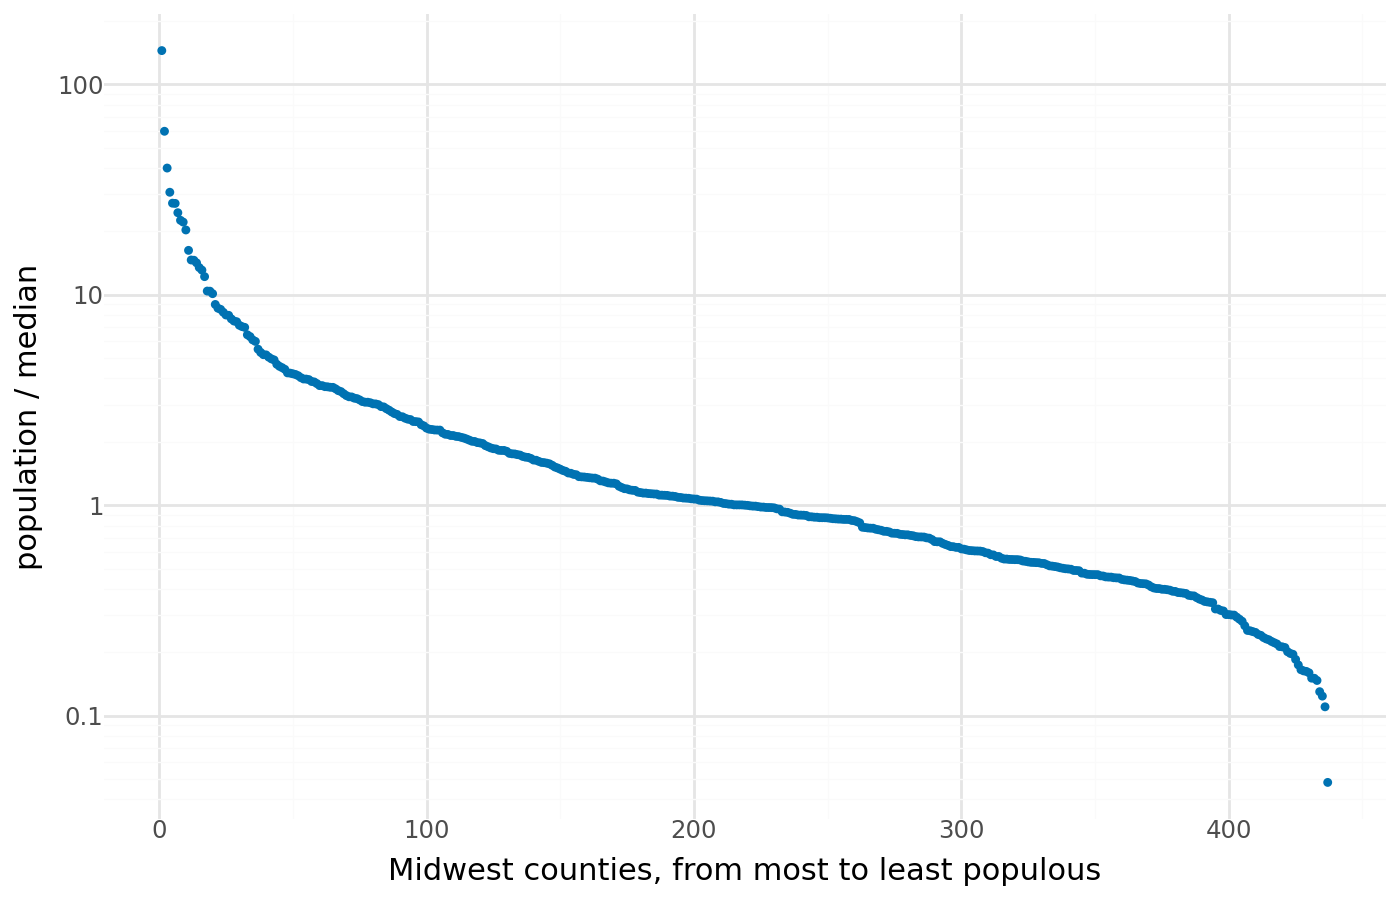

In [31]:
# ✅ 고친 그래프를 작성하세요
(
    ggplot(county, aes(x="rank", y="ratio"))
    + geom_point(size=0.8, color="#0072B2")
    + scale_y_log10()
    + labs(
        x="Midwest counties, from most to least populous",
        y="population / median"
    )
)
# 무엇이 잘못됐는지 주석으로 적어 주세요:
# 데이터를 미리 로그 변환한 값인 log_ratio를 y축에 매핑했기 때문에 y축 눈금이 (1,10,100)이 아닌 로그 변환된 수치 (0,1,2)가 표시되어 축 제목(population/ median)과 일치하지 않게 됩니다.

### 문제 2-3 📝
인구 데이터가 아니라 **0이 포함된 데이터**(예: 연간 사고 건수)를 로그 스케일로 그리면 어떤 문제가 생길까요? 세션에서 소개한 대안 스케일은 무엇인가요?

**✍️ 답:** log(0)은 항상 발산하므로 0 값은 로그스케일에 표현할 수 없다. 세션에서는 이를 해결하기 위해 제곱근 스케일을 소개했다. 제곱근 스케일은 0이 포함된 데이터도 문제 없이 시각화 할 수 있다.

## 3. 색상 스케일

세션에서 배운 색상의 세 가지 목적은 다음과 같습니다.
1. **데이터 그룹 구분**: 정성적 스케일
2. **데이터 값 표현**: 순차적 스케일, 발산형 스케일
3. **특정 값 강조**: 강조 스케일

### 준비: 제조사별 평균 고속도로 연비
`mpg` 데이터의 제조사에 **제조국** 정보를 붙입니다.

In [6]:
COUNTRY = {
    "audi": "Germany", "volkswagen": "Germany",
    "chevrolet": "USA", "dodge": "USA", "ford": "USA", "jeep": "USA",
    "lincoln": "USA", "mercury": "USA", "pontiac": "USA",
    "honda": "Japan", "nissan": "Japan", "subaru": "Japan", "toyota": "Japan",
    "hyundai": "Korea", "land rover": "UK",
}

maker = mpg.groupby("manufacturer", as_index=False, observed=True)["hwy"].mean()
maker["country"] = maker["manufacturer"].map(COUNTRY)
maker.head()

,manufacturer,hwy,country
0,audi,26.444444,Germany
1,chevrolet,21.894737,USA
2,dodge,17.945946,USA
3,ford,19.360000,USA
4,honda,32.555556,Japan


### 문제 3-1 (빈칸) — 정성적 스케일
슬라이드 21처럼 **연비 순으로 정렬한 가로 막대 그래프**를 그리고, 막대 색으로 **제조국**을 구분하세요.
- 막대 순서: `reorder(manufacturer, hwy)`를 쓰면 hwy 값 순서로 정렬됩니다.
- 색상: 순서가 없는 그룹이므로 `OKABE_ITO` 팔레트를 사용합니다.

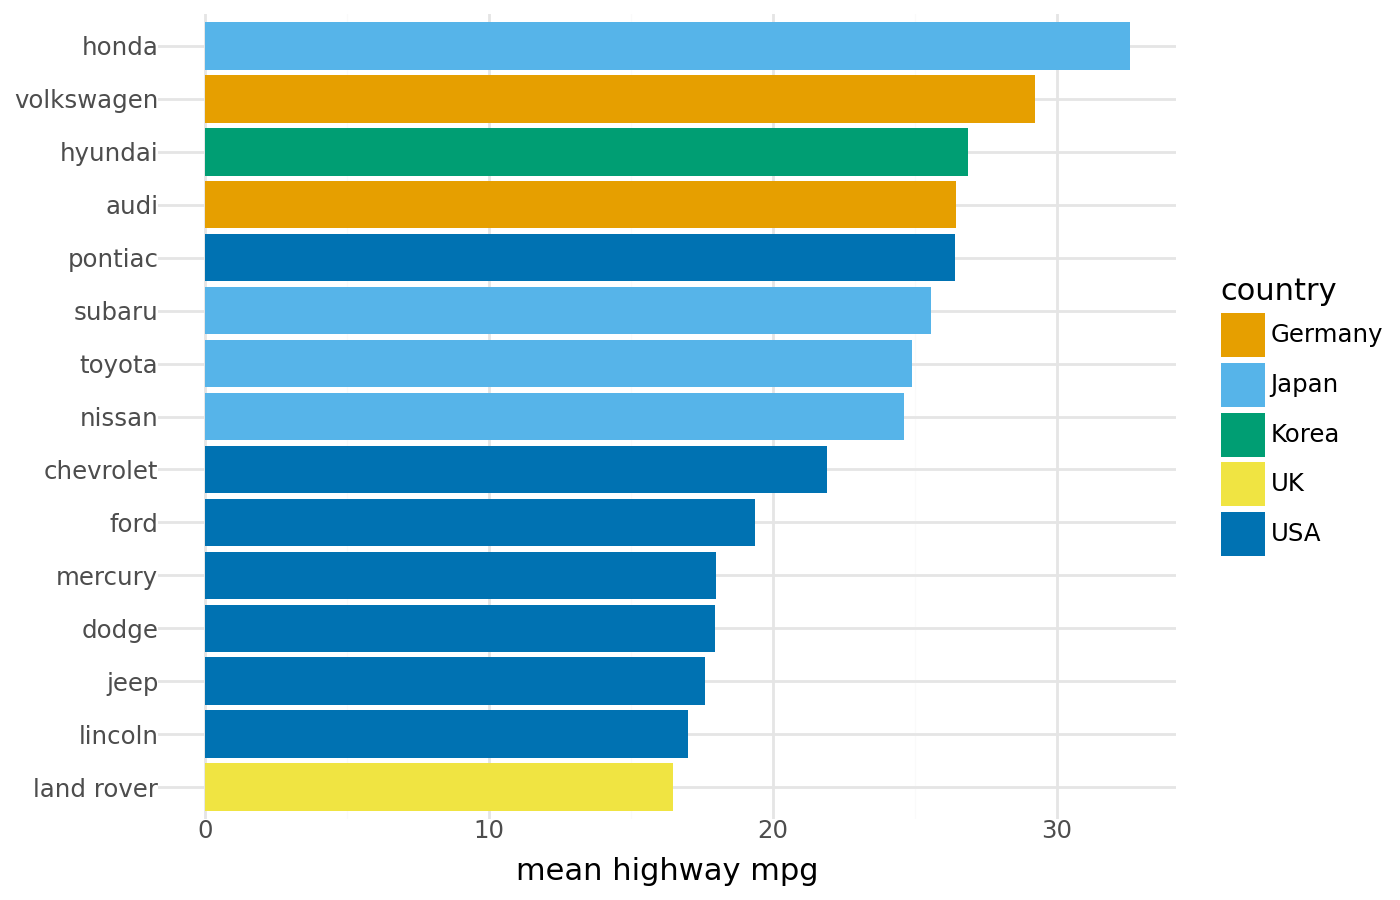

In [7]:
(
    ggplot(maker, aes(x="reorder(manufacturer, hwy)", y="hwy", fill="country"))    # TODO: 정렬된 제조사, 색상으로 구분할 변수
    + geom_col()
    + coord_flip()                                            # TODO: 막대를 가로로
    + scale_fill_manual(values=OKABE_ITO)                  # TODO: 정성적 팔레트
    + labs(x="", y="mean highway mpg", fill="country")
)

### 문제 3-2 (빈칸) — 강조 스케일
이번에는 **한국 제조사(hyundai)만 강조**하려고 합니다. 슬라이드 27처럼 나머지는 평이한 회색으로 두고, hyundai만 강렬한 색으로 칠하세요.

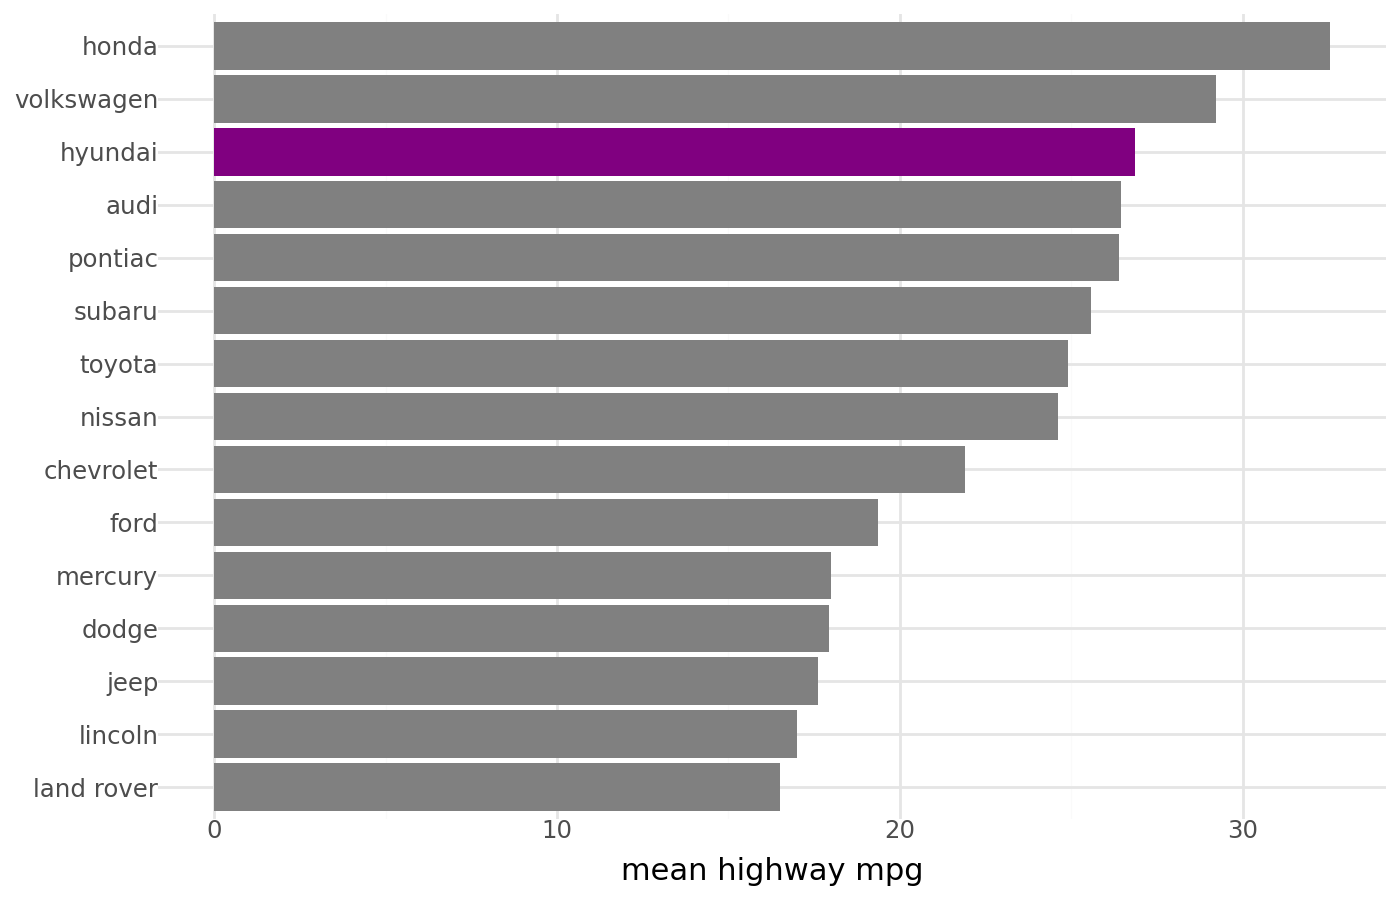

In [8]:
maker["highlight"] = np.where(maker["manufacturer"] == "hyundai", "hyundai", "other")   # TODO

(
    ggplot(maker, aes(x="reorder(manufacturer, hwy)", y="hwy", fill="highlight"))
    + geom_col()
    + coord_flip()
    + scale_fill_manual(values={"hyundai": "purple", "other": "gray"}, guide=None)        # TODO: 강조색 / 기본색
    + labs(x="", y="mean highway mpg")
)

### 문제 3-3 (빈칸) — 순차적 스케일 히트맵
슬라이드 39~40의 인터넷 사용자 히트맵처럼, 텍사스 46개 도시의 **연도별 주택 가격 중위값**을 히트맵으로 그립니다.
- 도시 순서는 **중위값이 처음으로 $150,000을 넘긴 연도** 기준입니다. 슬라이드 40과 같은 방식이에요.
- 값의 크기를 표현하므로 **순차적** 컬러맵 `magma`를 사용하세요.

In [9]:
tx = (
    txhousing.dropna(subset=["median"])
    .query("year <= 2014")
    .groupby(["city", "year"], as_index=False, observed=True)["median"].mean()
)

# 처음으로 $150,000을 넘긴 연도 (끝까지 못 넘기면 2100) → 빨리 넘긴 도시가 위로 오도록 정렬
first_year = (
    tx[tx["median"] >= 150_000].groupby("city", observed=True)["year"].min()
    .reindex(tx["city"].unique()).fillna(2100)
)
last_value = tx[tx["year"] == 2014].set_index("city")["median"].reindex(first_year.index)
order = (
    pd.DataFrame({"first": first_year, "last": last_value})
    .sort_values(["first", "last"], ascending=[False, True]).index
)
tx["city"] = pd.Categorical(tx["city"], categories=order)

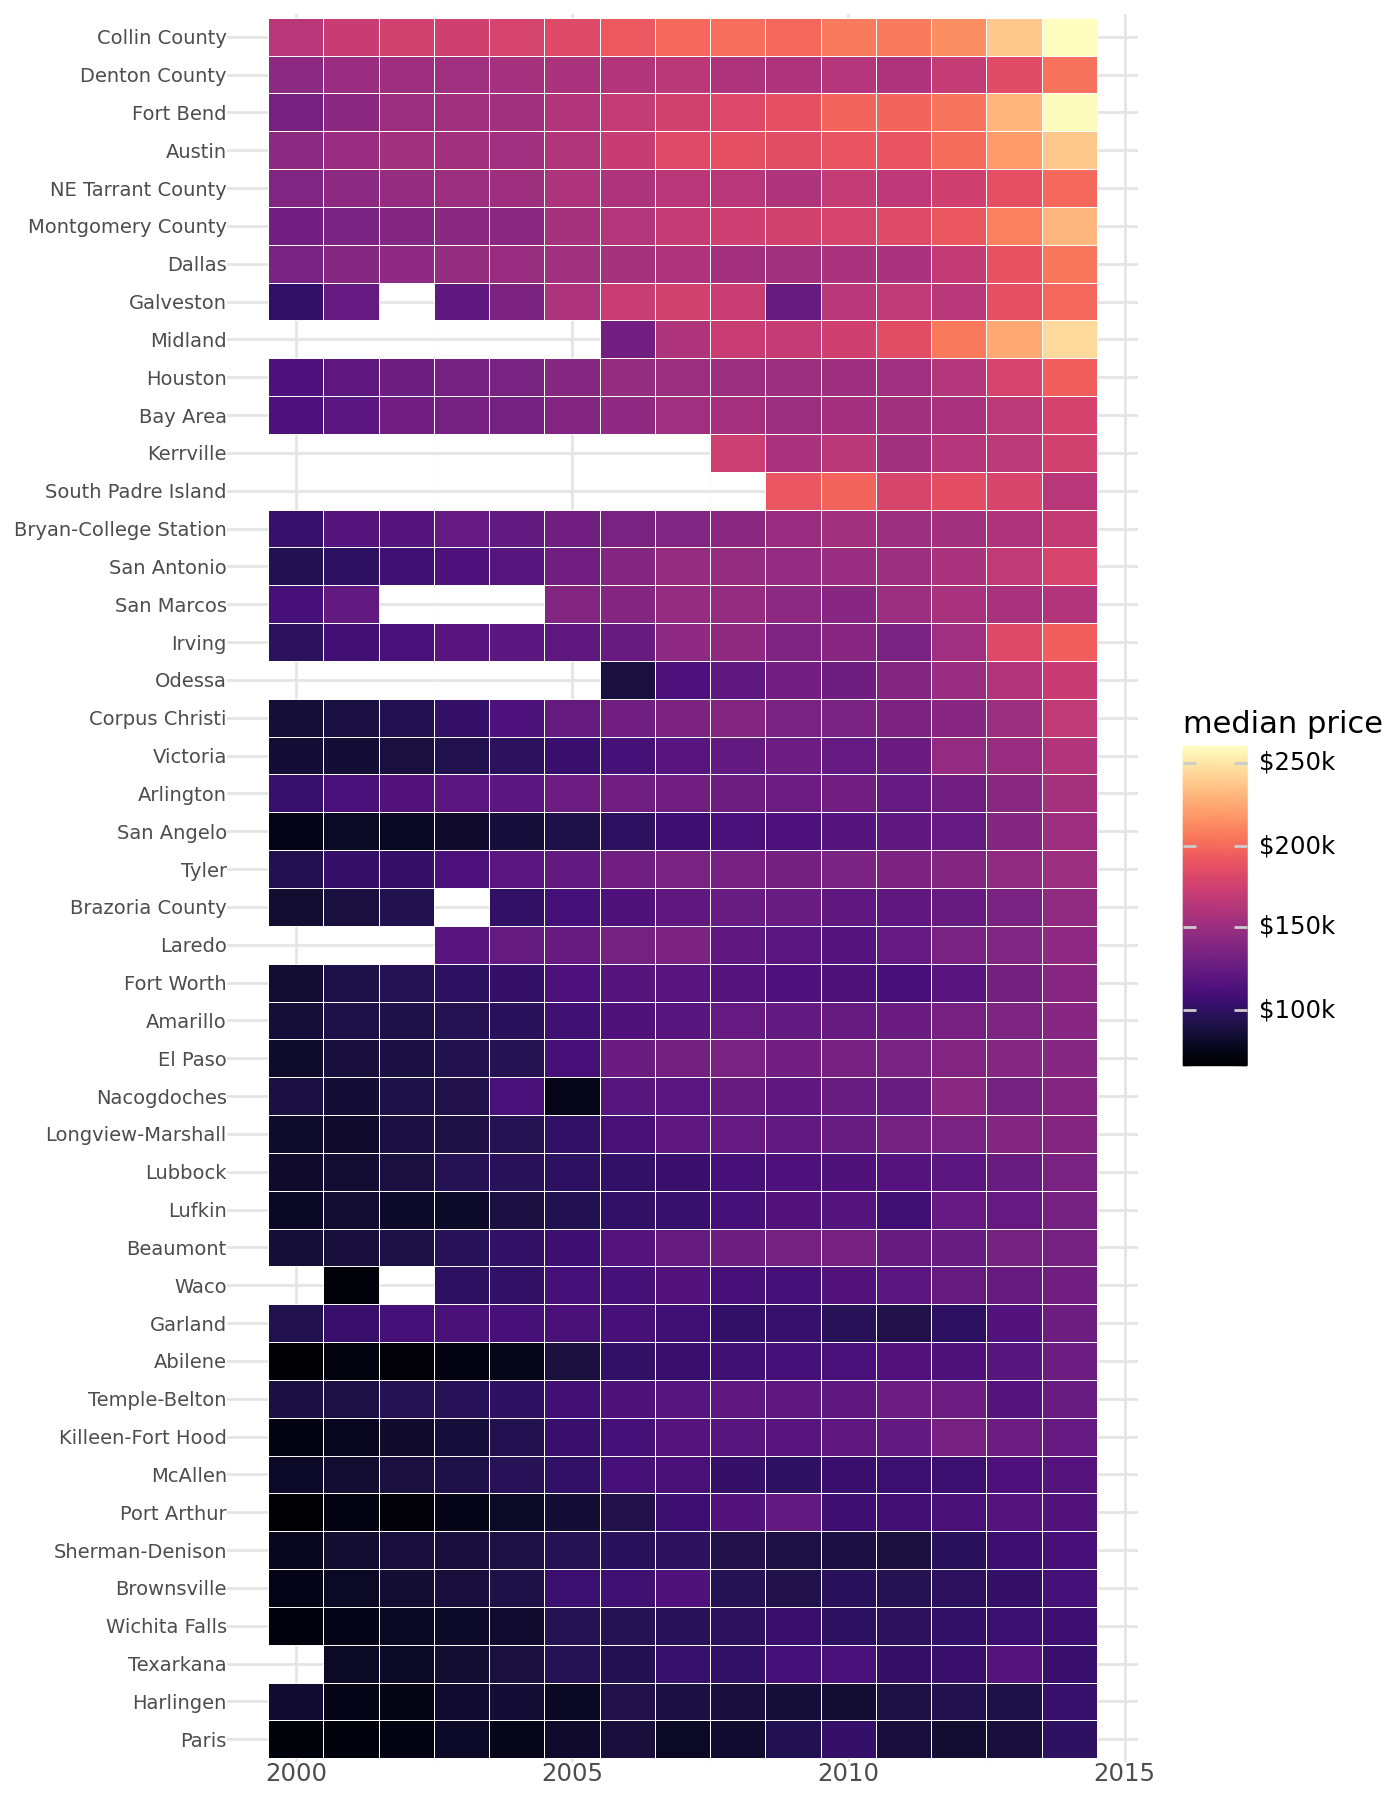

In [32]:
(
    ggplot(tx, aes(x="year", y="city", fill="median"))       # TODO: 색으로 표현할 값
    + geom_tile(color="white", size=0.2)                       # TODO: 히트맵을 그리는 geom
    + scale_fill_cmap("magma", labels=lambda v: [f"${x/1000:.0f}k" for x in v])   # TODO: 순차적 컬러맵
    + labs(x="", y="", fill="median price")
    + theme(figure_size=(7, 9), axis_text_y=element_text(size=7))
)

### 문제 3-4 (빈칸) — 발산형 스케일
이번에는 각 도시의 **연도별 월평균 주택 거래량(sales)이 그 도시의 전체 평균보다 몇 % 많거나 적은지** 표현합니다.
값에 **양수와 음수가 섞여 있고 0이 기준점**이므로, 0을 중립색(흰색)에 맞춘 발산형 스케일을 사용하세요.

In [12]:
sales = (
    txhousing.dropna(subset=["sales"])
    .query("year <= 2014")
    .groupby(["city", "year"], as_index=False, observed=True)["sales"].mean()   # 월평균 (기록이 일부 달만 있는 해도 공정하게 비교)
)
sales["pct_diff"] = sales.groupby("city")["sales"].transform(lambda s: (s / s.mean() - 1) * 100)
sales["city"] = pd.Categorical(sales["city"], categories=order)   # 3-3과 같은 도시 순서

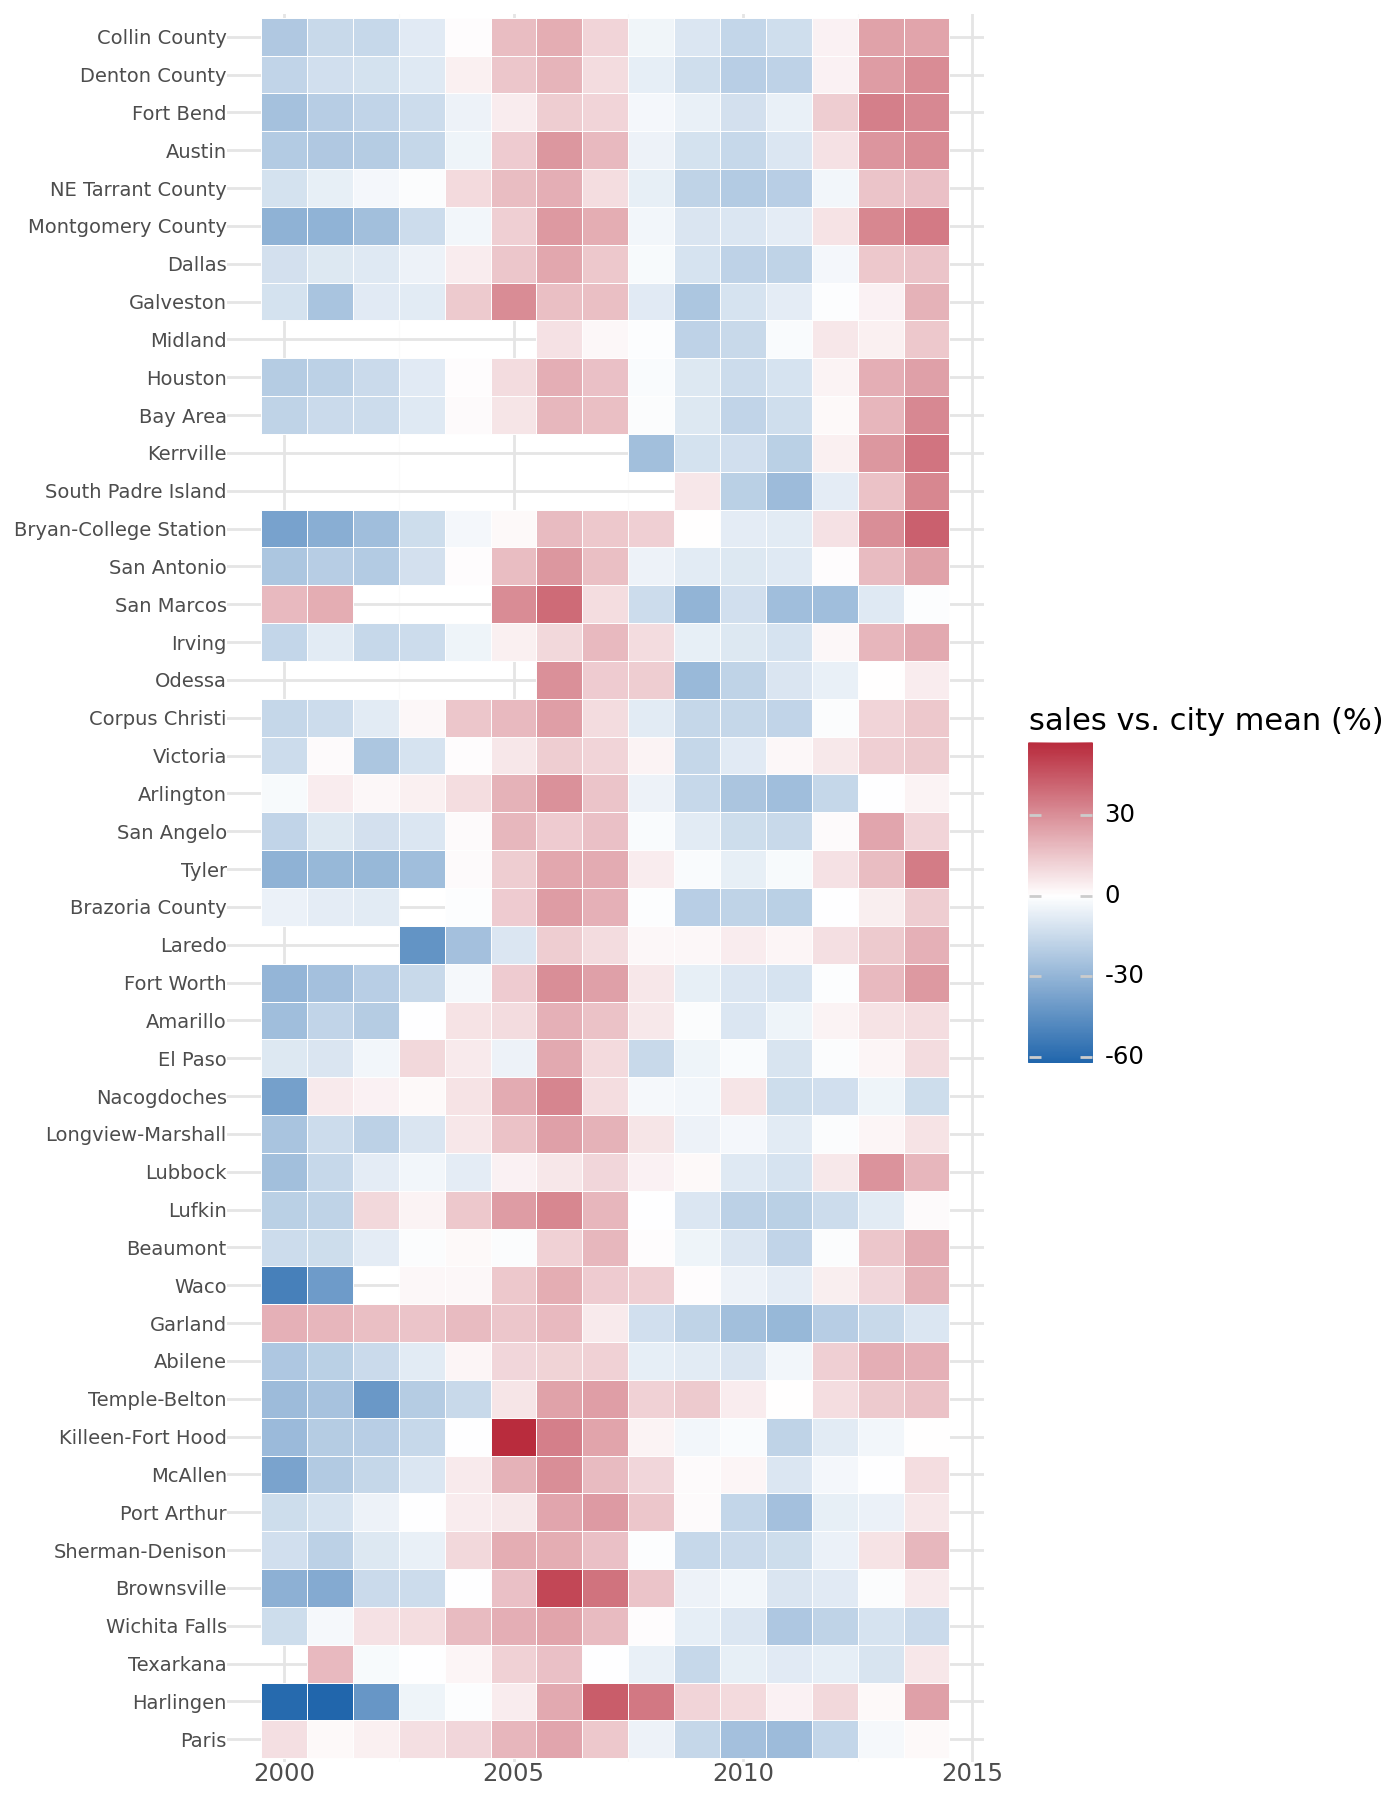

In [13]:
(
    ggplot(sales, aes(x="year", y="city", fill="pct_diff"))
    + geom_tile(color="white", size=0.2)
    + scale_fill_gradient2(low="#2166AC", mid="white", high="#B2182B", midpoint=0)   # TODO
    + labs(x="", y="", fill="sales vs. city mean (%)")
    + theme(figure_size=(7, 9), axis_text_y=element_text(size=7))
)

### 문제 3-5 📝
1. 3-3에는 순차적 스케일을, 3-4에는 발산형 스케일을 쓴 이유를 설명하세요.
2. 3-4 히트맵에서 텍사스 주택 시장에 대해 읽어낼 수 있는 패턴 하나를 적어 보세요.

**✍️ 답:**
(1) 3-3의 연속형 변수의 연속성을 표현하는데에는 순차적 스케일이 적합하다. 값의 크기나 색상 명암으로 직관적으로 전달하기 위해 순차적 스케일을 사용했다.
3-4에서는 명확한 기준점을 중심으로 양방향의 편차를 강조하기 위해 발산형 스케일을 사용했다.

(2) 2000-2003년에서는 전반적으로 도시의 판매량이 해당 기간 도시 평균 대비 낮았거나 감소세를 보였고, 2005-2007년에는 도시의 판매량이 도시 평균 대비 크게 증가하는 양상을 보였다.

## 4. 수량 데이터의 시각화

### 문제 4-1 🔧 고치기 — 막대도표
아래는 2014년 주택 거래량 상위 12개 도시를 그린 그래프입니다. 슬라이드 30에서 *조악함*으로 지적한 문제가 있습니다.
**정렬된 가로 막대 그래프**로 고치세요.

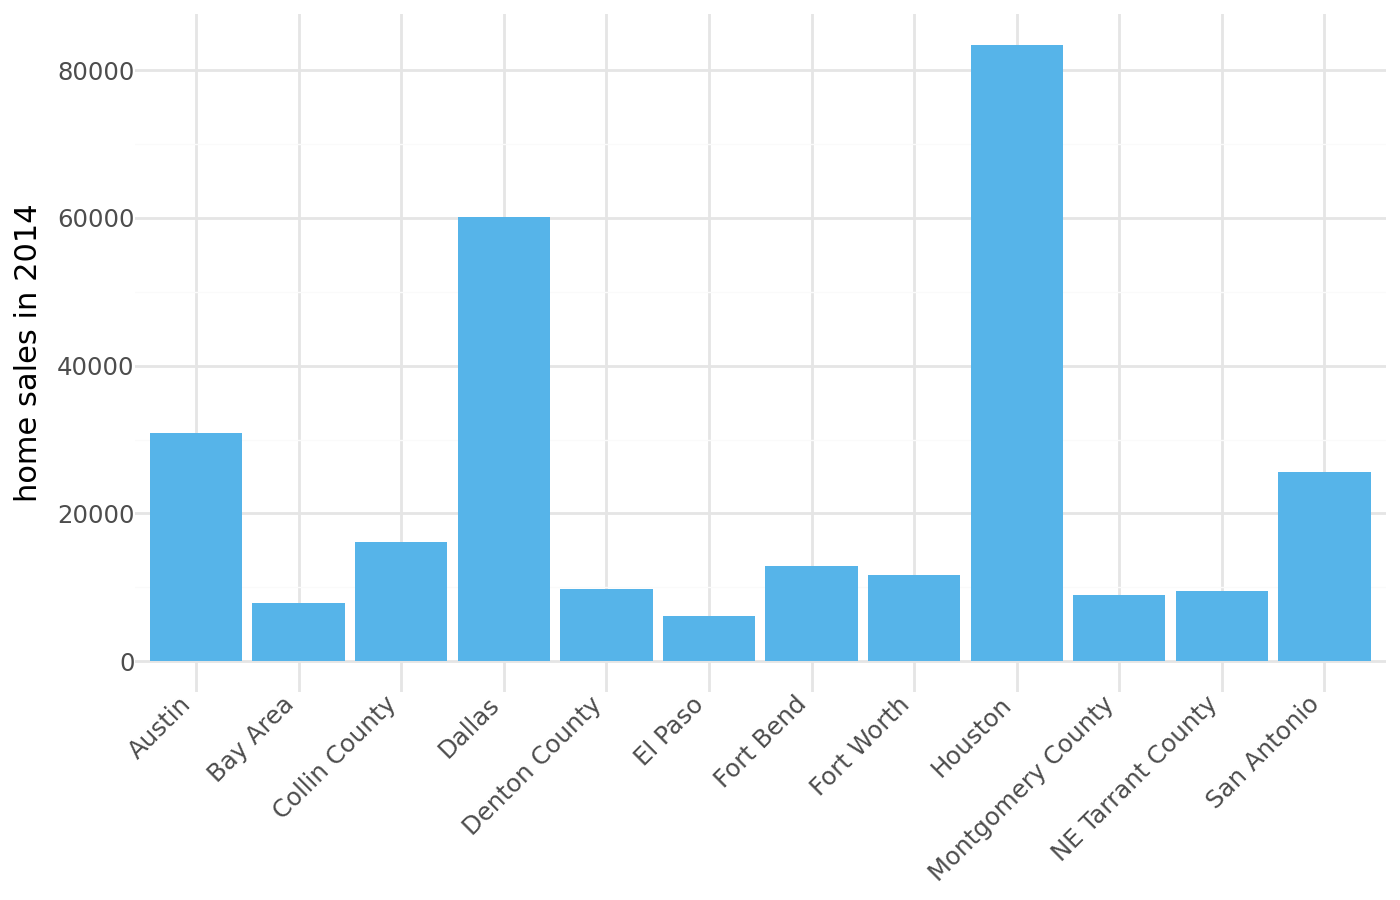

In [14]:
top12 = (
    txhousing.query("year == 2014").groupby("city", as_index=False)["sales"].sum()
    .nlargest(12, "sales")
    .sample(frac=1, random_state=7)   # 일부러 순서를 섞음
)

# ❌ 조악한 그래프 (그대로 두세요)
(
    ggplot(top12, aes(x="city", y="sales"))
    + geom_col(fill="#56B4E9")
    + theme(axis_text_x=element_text(rotation=45, ha="right"))
    + labs(x="", y="home sales in 2014")
)

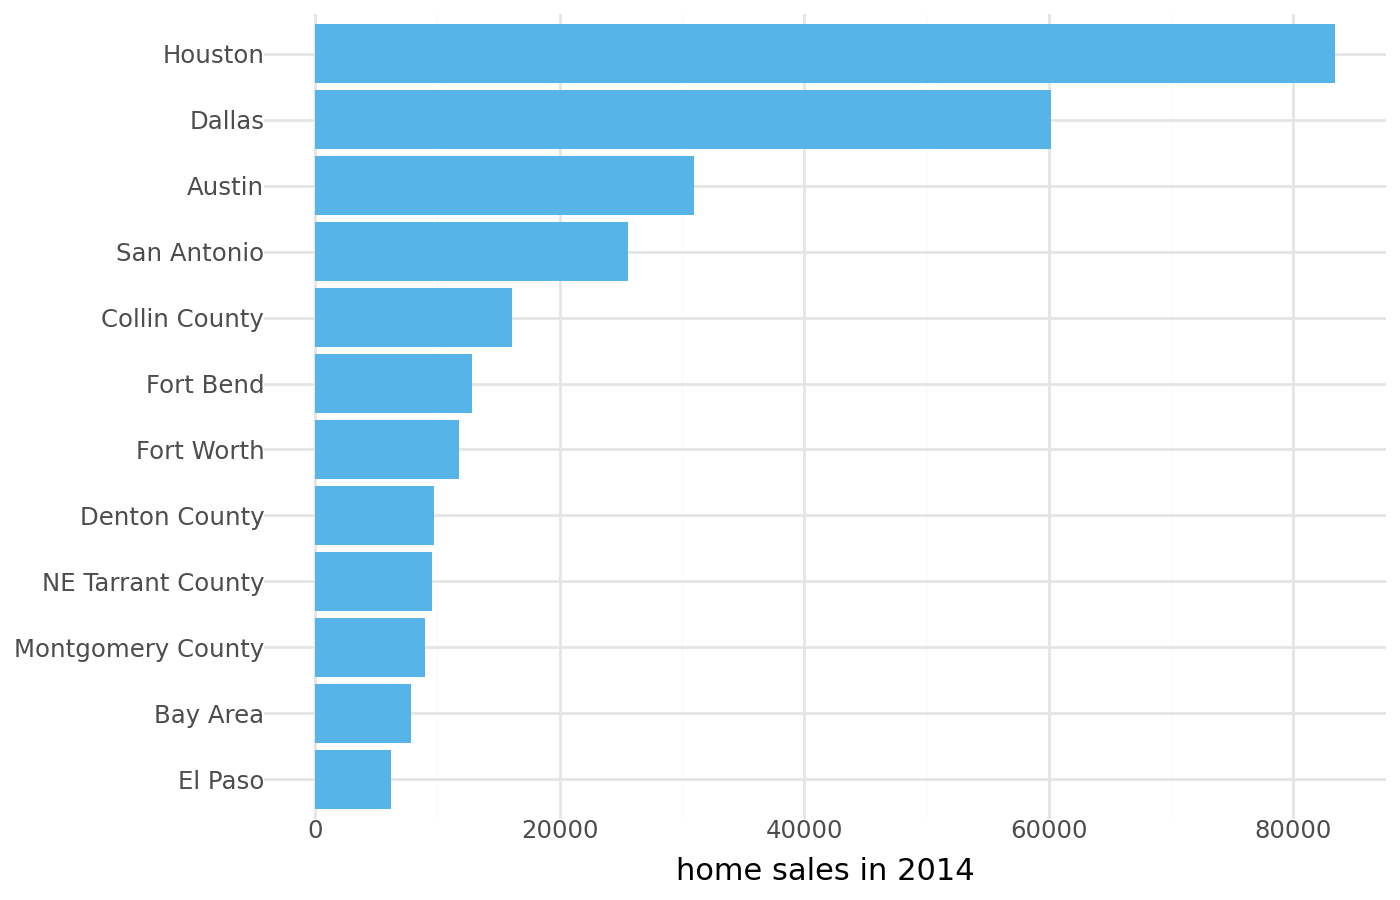

In [15]:
# ✅ 고친 그래프를 작성하세요
(
    ggplot(top12, aes(x="reorder(city, sales)", y="sales"))
    + geom_col(fill="#56B4E9")
    + coord_flip()
    + labs(x="", y="home sales in 2014")
)

### 문제 4-2 🔧 고치기 — 순서가 있는 범주
아래는 휴스턴의 **월별 평균 주택 거래량**입니다. 4-1과 똑같이 값 순서로 정렬했는데, 슬라이드 32에 따르면 이번에는 오히려 *모호한* 그래프가 됩니다.
올바른 순서로 고치세요.

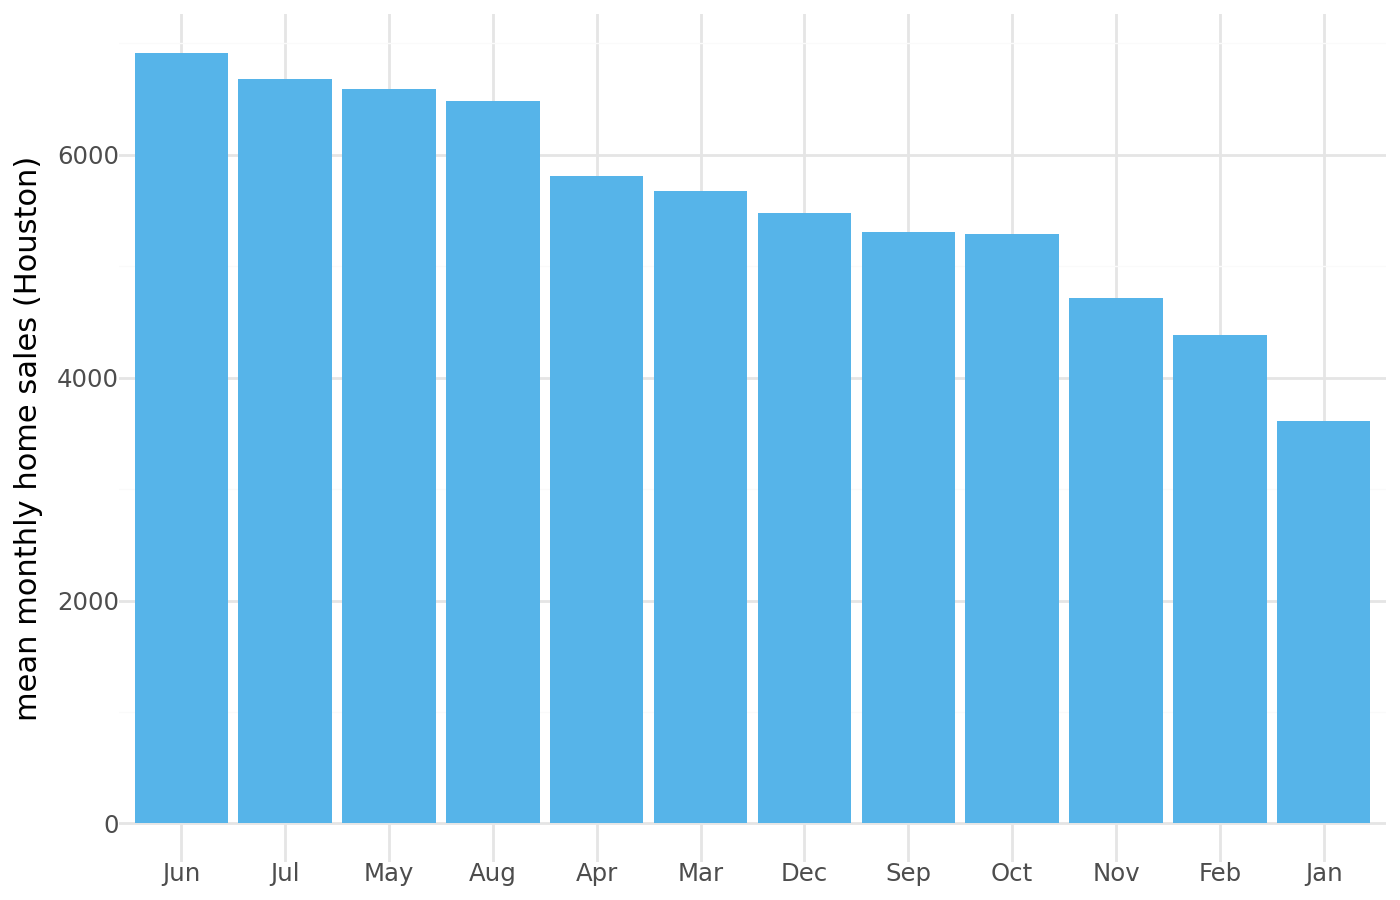

In [16]:
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

houston = txhousing.query("city == 'Houston'").groupby("month", as_index=False)["sales"].mean()
houston["month_name"] = [MONTHS[m - 1] for m in houston["month"]]

# ❌ 모호한 그래프 (그대로 두세요)
(
    ggplot(houston, aes(x="reorder(month_name, -sales)", y="sales"))
    + geom_col(fill="#56B4E9")
    + labs(x="", y="mean monthly home sales (Houston)")
)

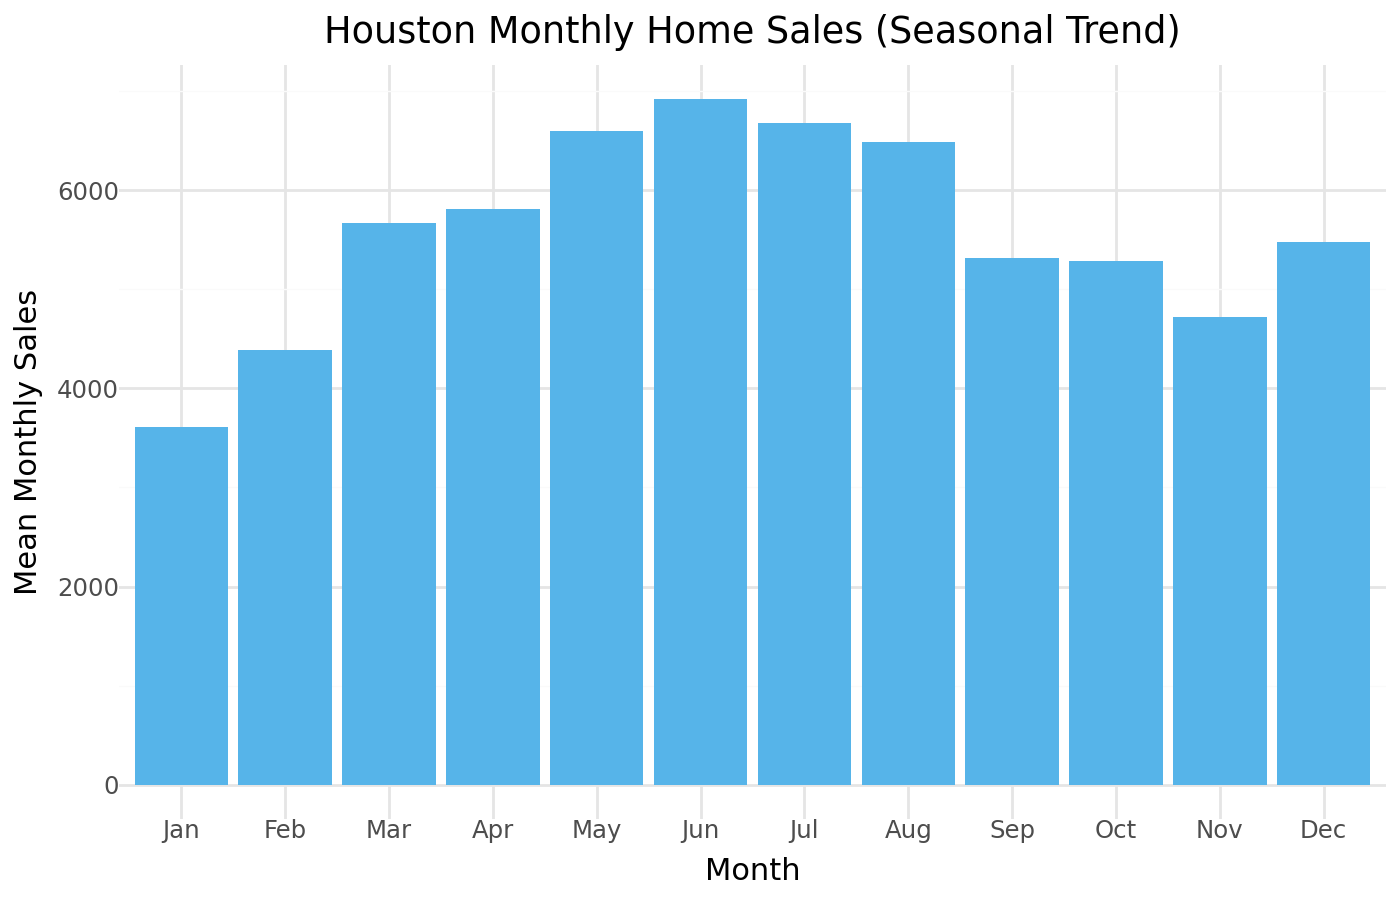

In [17]:
# ✅ 고친 그래프를 작성하세요 (힌트: pd.Categorical(..., categories=MONTHS, ordered=True))
(
    ggplot(houston, aes(x="reorder(month_name, month)", y="sales"))
    + geom_col(fill="#56B4E9")
    + labs(
        title="Houston Monthly Home Sales (Seasonal Trend)",
        x="Month",
        y="Mean Monthly Sales"
    )
)

### 문제 4-3 (빈칸) — 묶은 막대 vs 누적 막대
슬라이드 36의 **타이타닉 객실 등급별 승객 수**입니다. 같은 데이터를 두 가지 방법으로 그려 보세요.

In [18]:
titanic = pd.DataFrame({
    "pclass": ["1st", "1st", "2nd", "2nd", "3rd", "3rd"],
    "sex":    ["female", "male"] * 3,
    "count":  [143, 179, 107, 172, 212, 499],
})
titanic

,pclass,sex,count
0,1st,female,143
1,1st,male,179
2,2nd,female,107
3,2nd,male,172
4,3rd,female,212
5,3rd,male,499


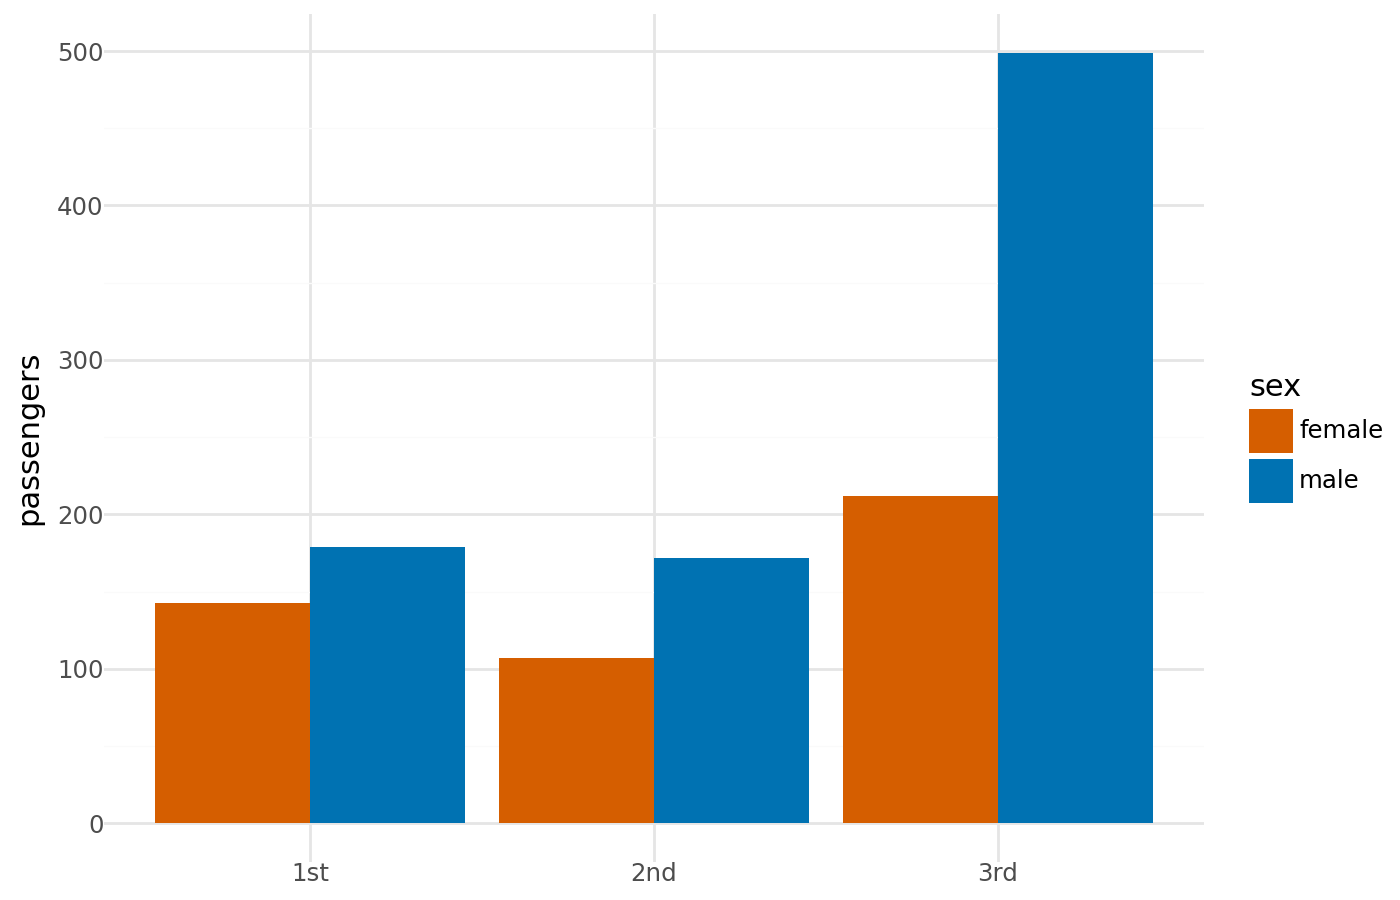

In [20]:
# (a) 묶은 막대: 성별을 나란히
(
    ggplot(titanic, aes(x="pclass", y="count", fill="sex"))
    + geom_col(position="dodge")                          # TODO
    + scale_fill_manual(values=["#D55E00", "#0072B2"])
    + labs(x="", y="passengers")
)

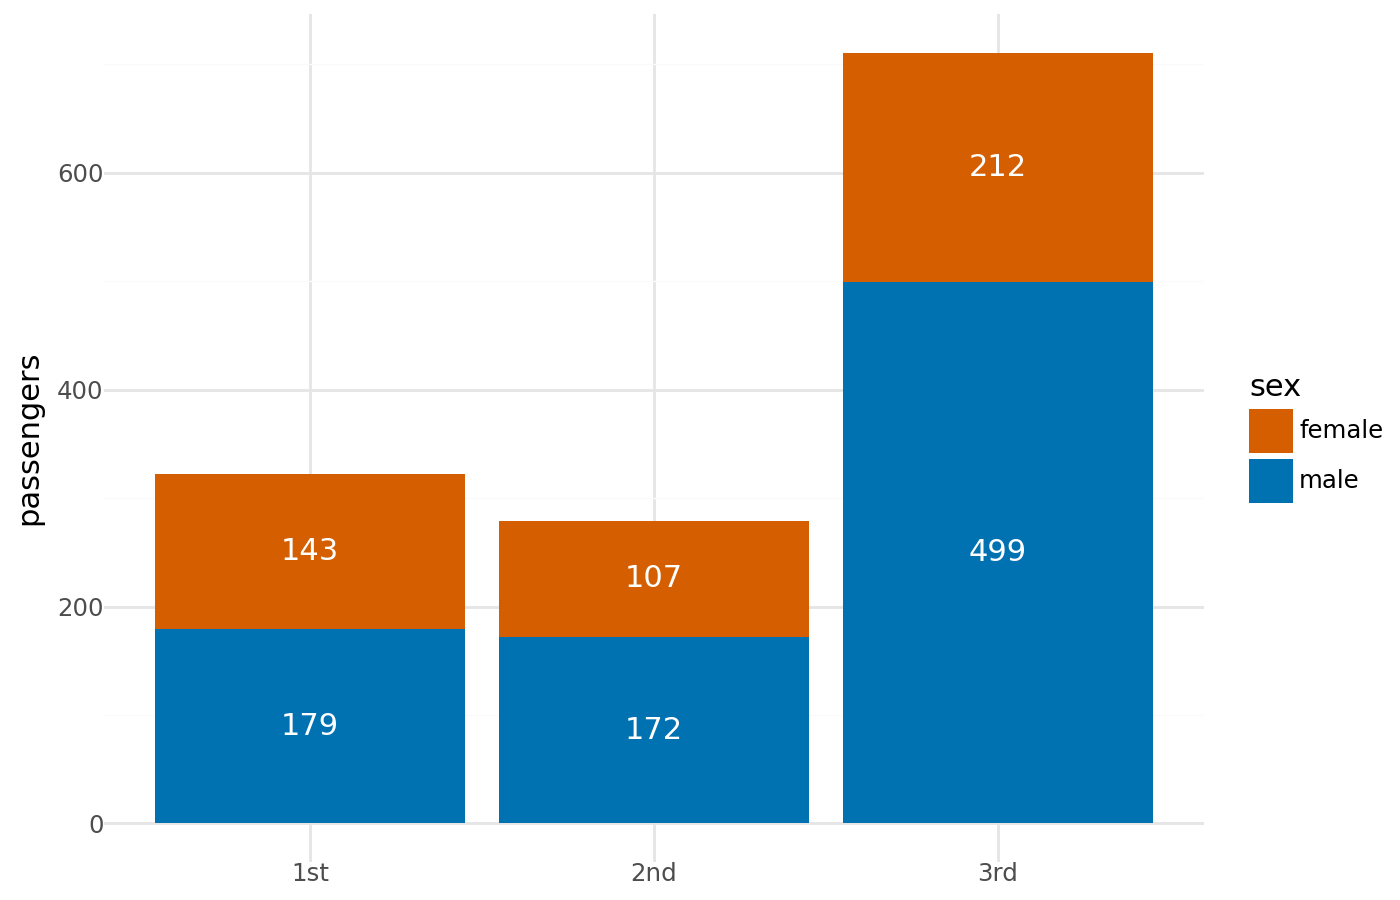

In [21]:
# (b) 누적 막대: 성별을 위로 쌓기 + 막대 안에 숫자 표시
(
    ggplot(titanic, aes(x="pclass", y="count", fill="sex"))
    + geom_col(position="stack")                          # TODO
    + geom_text(aes(label="count"), position=position_stack(vjust=0.5), color="white")
    + scale_fill_manual(values=["#D55E00", "#0072B2"])
    + labs(x="", y="passengers")
)

### 문제 4-4 📝
(a)와 (b) 중 **"3등실에 탄 승객이 전체적으로 가장 많다"** 는 사실을 보여주기에 더 좋은 그래프는 무엇이고, 그 이유는 무엇인가요?
반대로 **"각 등급에서 남성이 여성보다 몇 명 더 많은가"** 를 비교하기에는 어느 쪽이 나은가요?

**✍️ 답:**
3등실에 탄 승객이 전체적으로 가장 많다를 보여주기에 더 좋은 그래프는 (b) 누적 막대 그래프이다. 누적 막대 그래프는 각 범주(객실 등급)의 전체 합계가 막대의 전체 높이로 직접 표현된다. 따라서 개별 그룹의 수치를 눈으로 합산하지 않아도 3등실 막대의 전체 높이가 1, 2등실에 비해 월등히 높다는 사실을 한눈에 비교할 수 있다.

각 등급에서 남성이 여성보다 몇 명 더 많은가를 비교하기에 더 좋은 그래프는 (a) 묶은 막대 그래프이다. 묶은 막대 그래프는 동일한 등급 내에서 남성과 여성의 막대가 동일한 기준선(y=0) 위에 나란히 배치된다. 기준선이 같기 때문에 두 막대 간의 높이 차이를 정밀하게 비교하기 훨씬 수월하다.

### 문제 4-5 🔧 고치기 — 점 도표
2014년 텍사스 도시별 **주택 가격 중위값**을 막대로 그렸더니, 슬라이드 38처럼 막대 길이가 거의 비슷해 차이가 두드러지지 않습니다.
정렬된 **점 도표**로 고치세요.

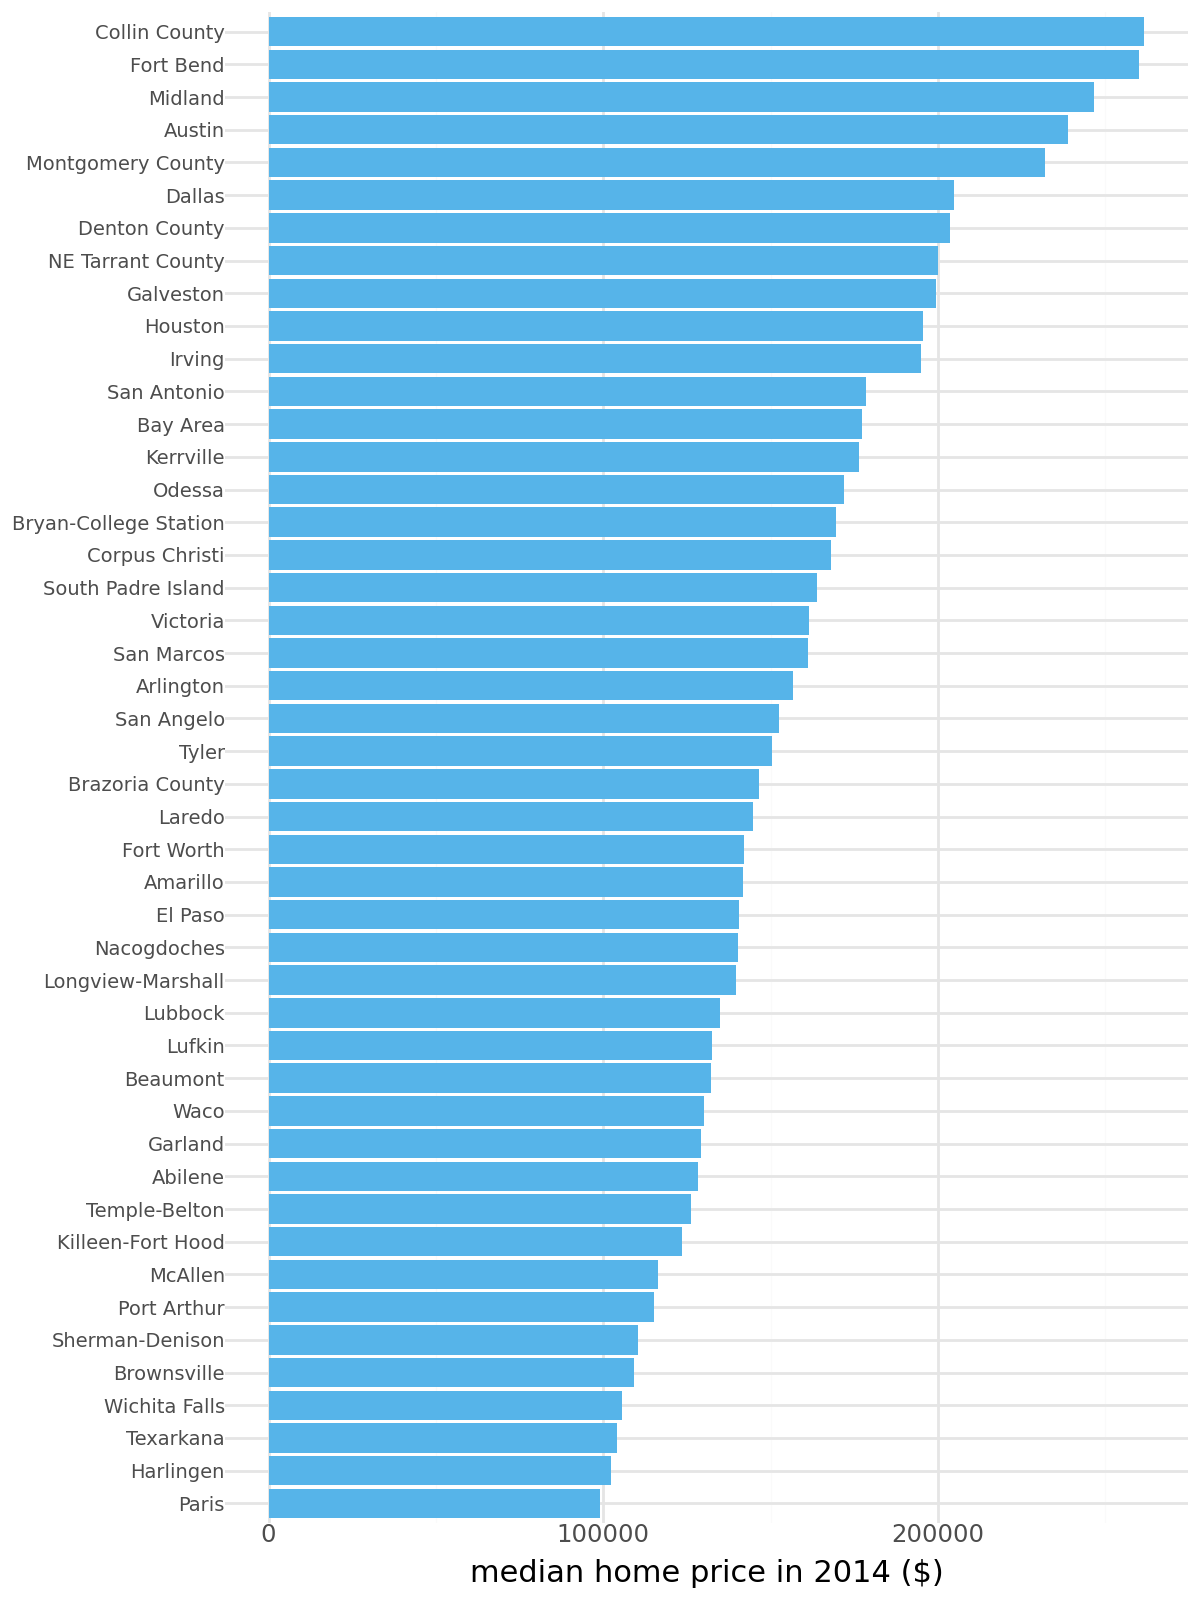

In [22]:
price14 = txhousing.query("year == 2014").groupby("city", as_index=False)["median"].mean().dropna()

# ❌ 모호한 그래프 (그대로 두세요)
(
    ggplot(price14, aes(x="reorder(city, median)", y="median"))
    + geom_col(fill="#56B4E9")
    + coord_flip()
    + labs(x="", y="median home price in 2014 ($)")
    + theme(figure_size=(6, 8), axis_text_y=element_text(size=7))
)

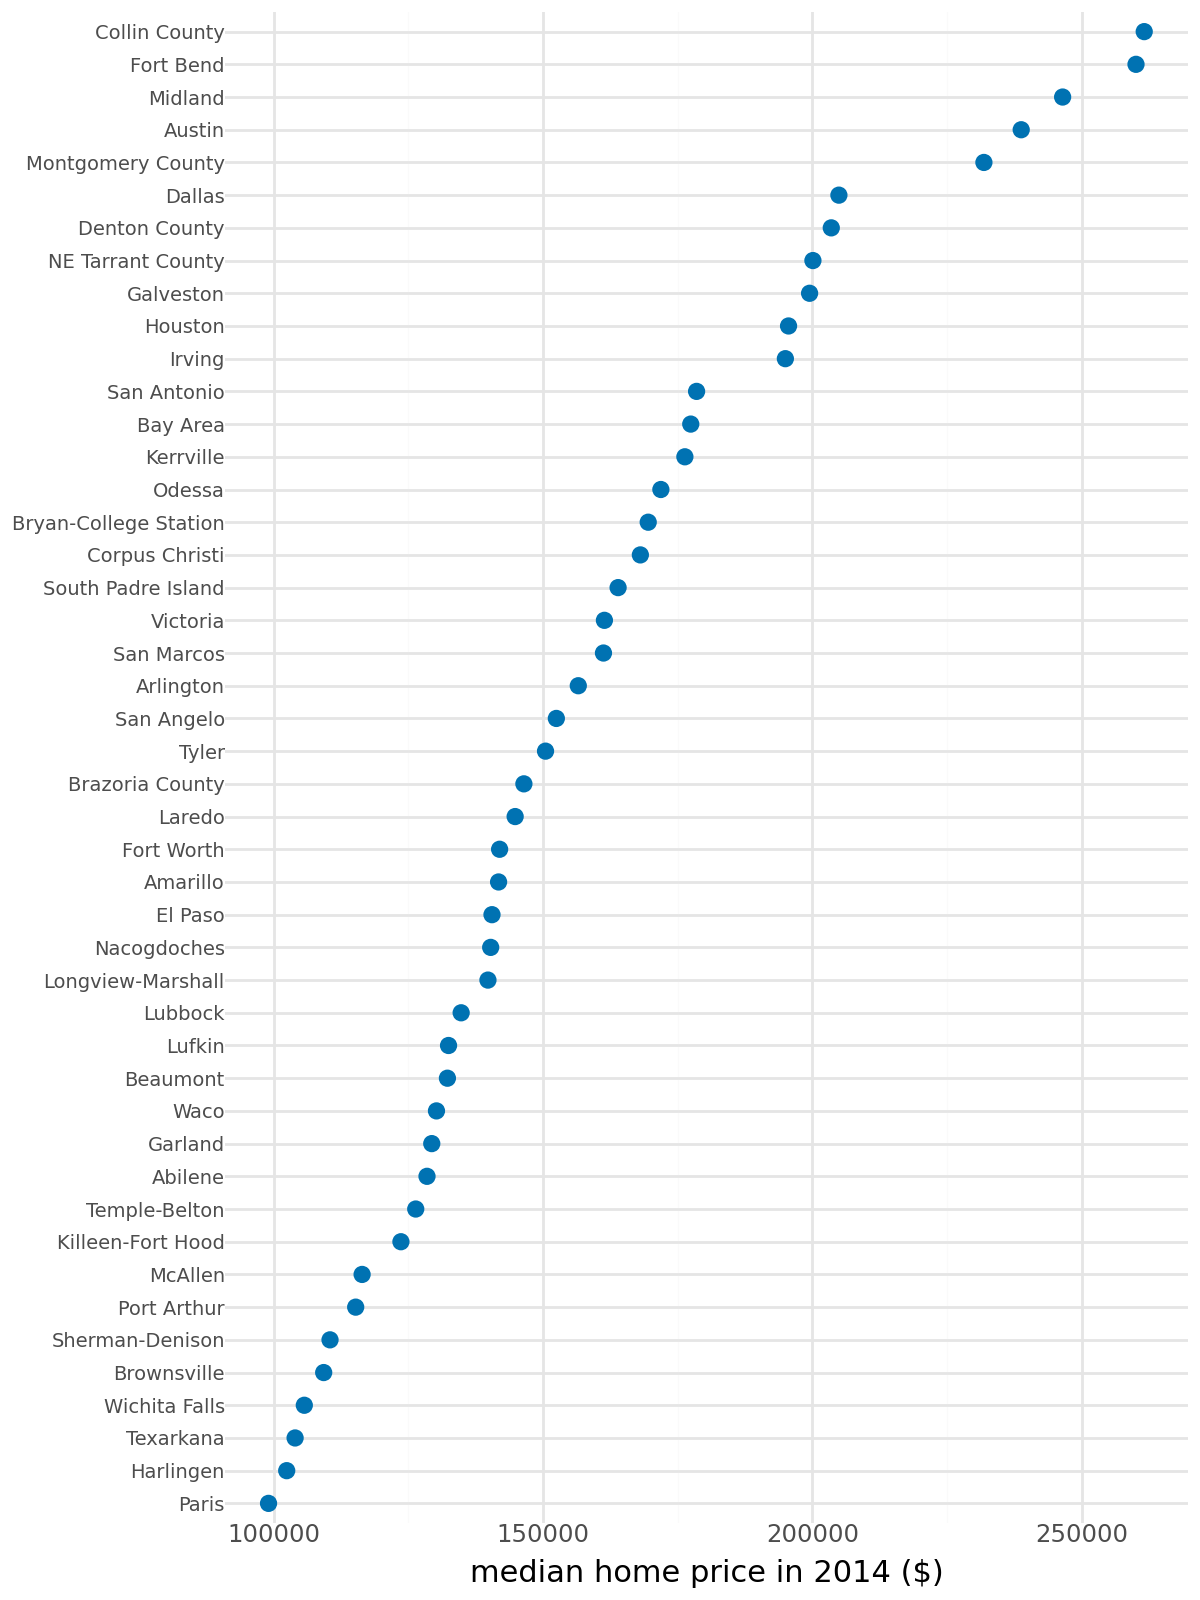

In [23]:
# ✅ 고친 그래프를 작성하세요
(
    ggplot(price14, aes(x="reorder(city, median)", y="median"))
    + geom_point(color="#0072B2", size=2.5)
    + coord_flip()
    + labs(x="", y="median home price in 2014 ($)")
    + theme(figure_size=(6, 8), axis_text_y=element_text(size=7))
)

### 문제 4-6 📝
막대도표에서는 **y축을 0이 아닌 곳에서 시작하면 안 되는데**, 점 도표에서는 괜찮은 이유는 무엇일까요?

**✍️ 답:** 막대 도표는 y축의 시작점을 0이 아닌 값으로 잘라내면 막대 길이의 비율과 실제 데이터 수치의 비율이 일치하지 않게 되어 시각적 왜곡을 일으킨다. 반면 점 도표는 길이의 비율이 아닌 점의 상대적 위치를 기준으로 비교하므로 축을 0부터 시작하지 않아도 왜곡없이 전달할 수 있다.

## 5. 분포 데이터의 시각화

`faithful`은 옐로스톤의 Old Faithful 간헐천 데이터이고, `waiting`은 분출 사이의 대기 시간(분)입니다.

### 문제 5-1 (빈칸) — 히스토그램의 구간 폭
구간 폭(`binwidth`)을 **1, 5, 10, 20분**으로 바꿔 가며 히스토그램 4개를 그리세요.

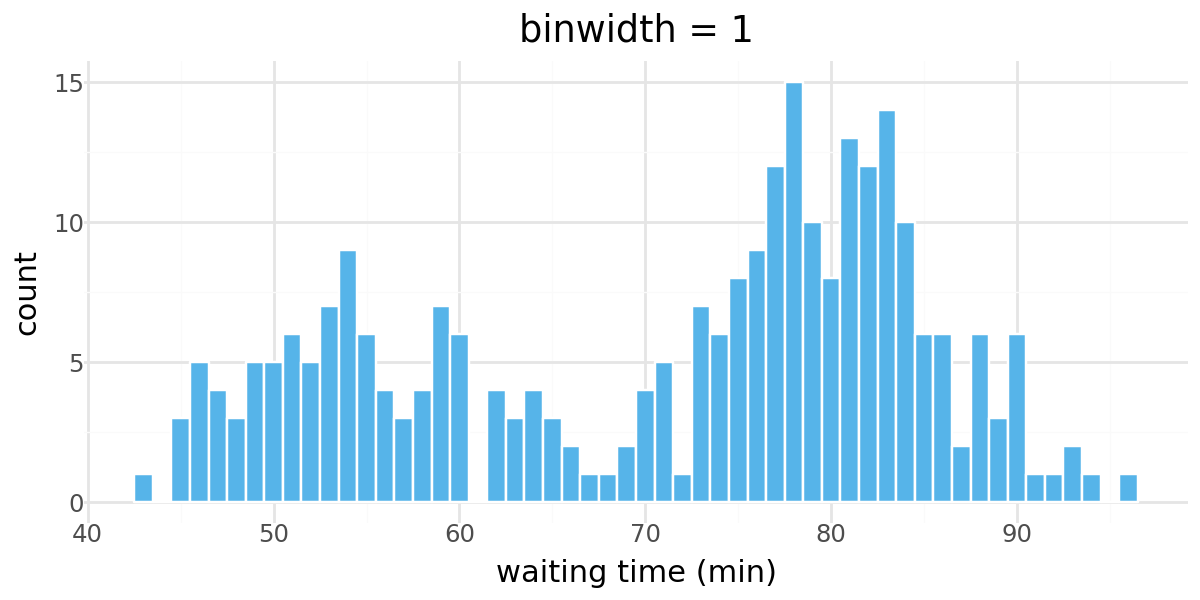

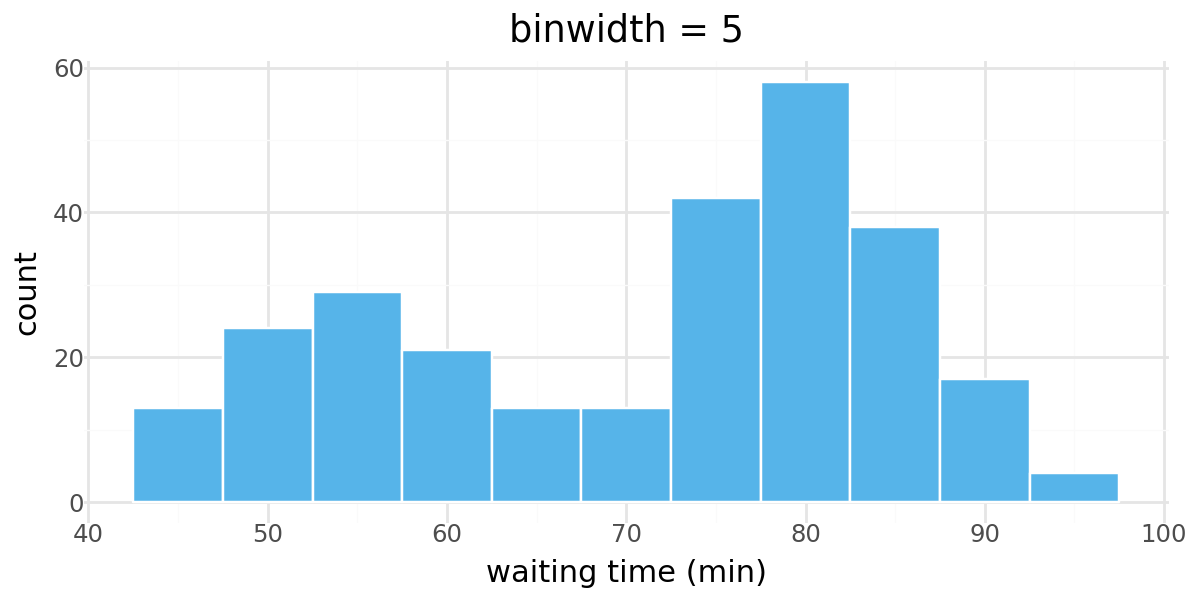

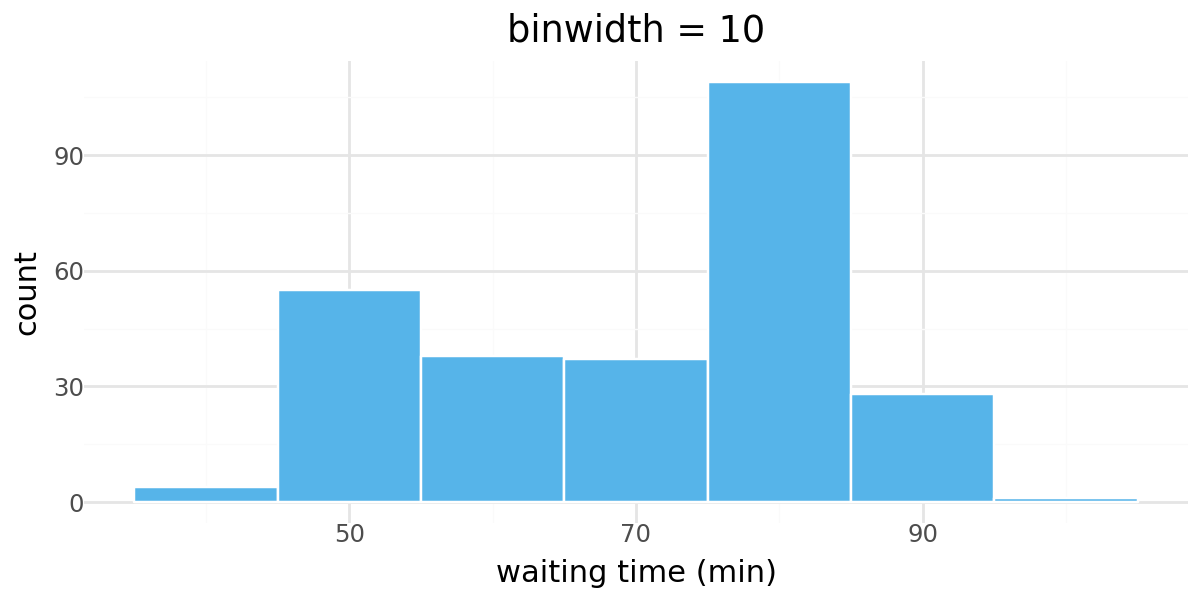

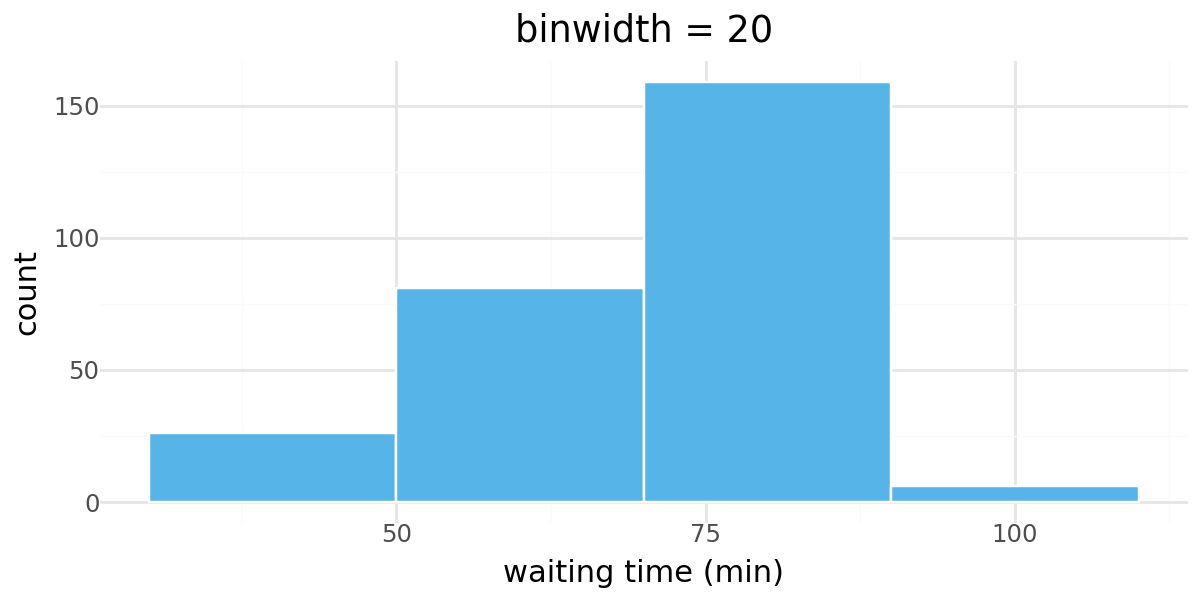

In [24]:
for bw in [1, 5, 10, 20]:
    display(
        ggplot(faithful, aes(x="waiting"))
        + geom_histogram(binwidth=bw, fill="#56B4E9", color="white")   # TODO
        + labs(title=f"binwidth = {bw}", x="waiting time (min)", y="count")
        + theme(figure_size=(6, 3))
    )

### 문제 5-2 (빈칸) — 밀도 도표의 대역폭
`geom_density`의 `adjust`는 기본 대역폭에 곱하는 배수입니다. `adjust`를 **0.2, 1, 3**으로 바꿔 가며 밀도 도표를 그리세요.

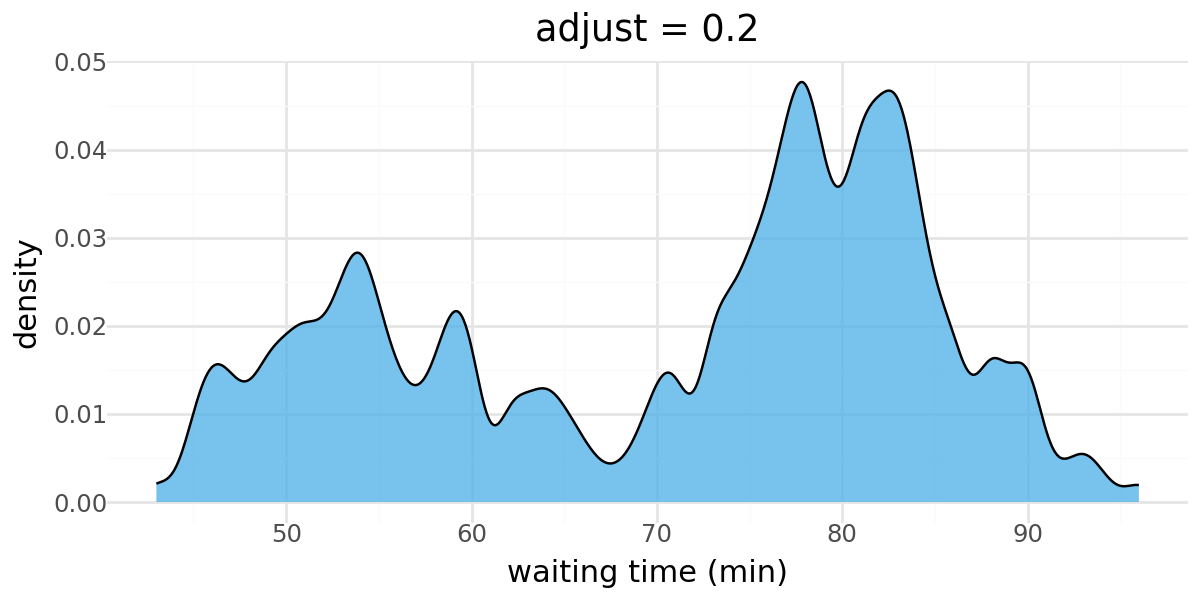

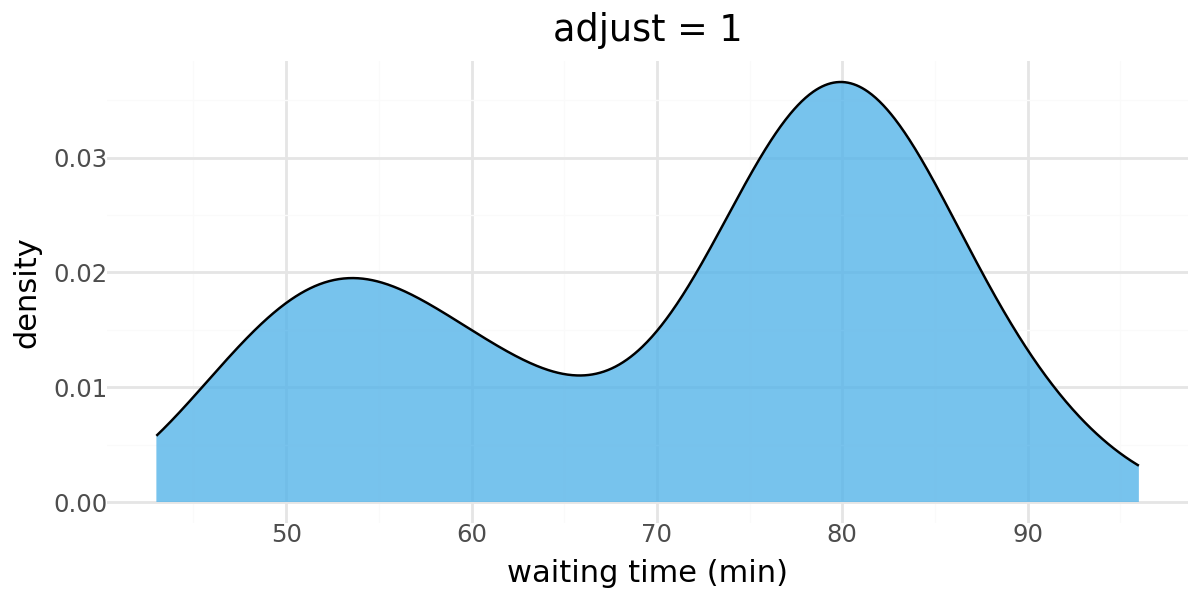

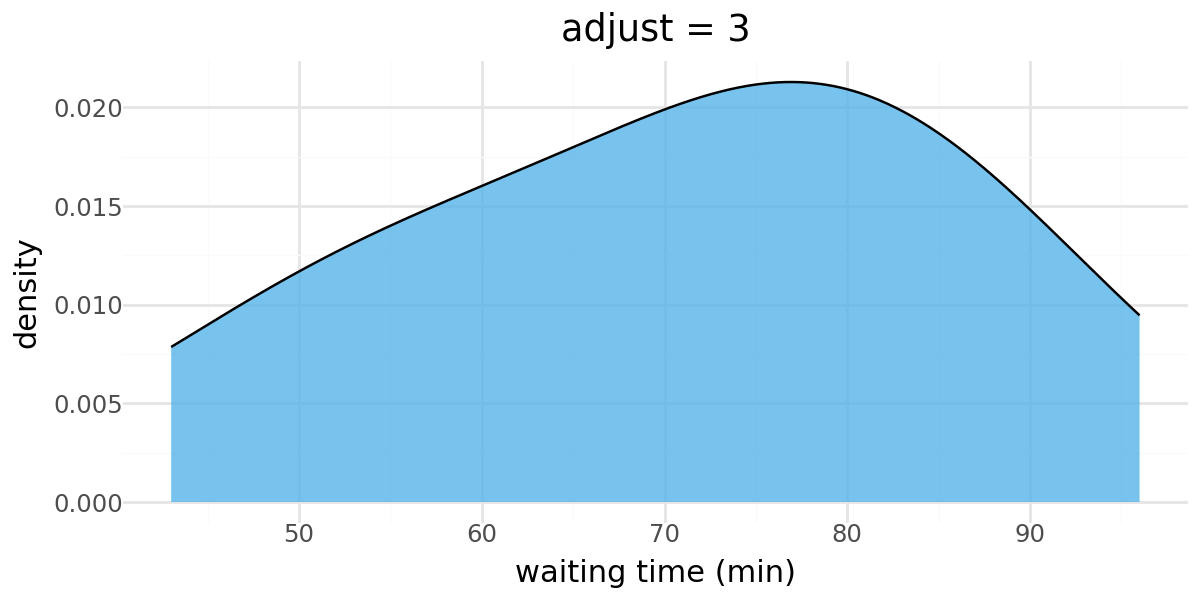

In [25]:
for adj in [0.2, 1, 3]:
    display(
        ggplot(faithful, aes(x="waiting"))
        + geom_density(adjust=adj, fill="#56B4E9", alpha=0.8)    # TODO: 밀도 도표 geom
        + labs(title=f"adjust = {adj}", x="waiting time (min)", y="density")
        + theme(figure_size=(6, 3))
    )

### 문제 5-3 📝
1. 5-1에서 구간 폭이 **너무 좁을 때**와 **너무 넓을 때** 각각 어떤 문제가 생기나요? 특히 binwidth = 20에서 사라지는 중요한 특징은 무엇인가요?
2. 5-2에서 대역폭을 크게 하면 그래프가 어떻게 변하나요? 데이터에 대해 어떤 오해를 할 수 있을까요?

**✍️ 답:**
1. 구간 폭이 너무 좁으면 데이터의 미세한 노이즈와 무작위 변동까지 과도하게 표출되어 전체적인 형태를 파악하기 어렵고 구간 폭이 너무 넓으면 세부적인 데이터 정보가 과도하게 합쳐져 실제 데이터가 지닌 중요한 구조적 특징을 상쇄시킨다. binwidth = 20 에서는 대기 시간이 짧은 그룹과 긴 그룹으로 구분됐던 봉우리가 사라지고 하나의 봉우리로 통합되는 문제가 생겼다.

2.대역폭의 계수를 크게 하면 커널 밀도 추정 곡선이 과도하게 평활화되어 곡선의 변동성이 줄어들고 완만해진다. 데이터가 실제로는 두 개의 군집으로 나뉘어 있음에도 불구하고 단일 정규분포 형태를 띈다고 오인할 수 있다.

### 문제 5-4 🔧 고치기 — 여러 분포 비교
펭귄 3종의 **몸무게 분포**를 비교하려고 누적 히스토그램을 그렸습니다. 슬라이드 46처럼 막대의 시작 위치가 제각각이라 각 종의 분포를 읽기 어렵습니다.
슬라이드 51처럼 **반투명한 중첩 밀도 도표**로 고치고, 범례 대신 곡선 옆에 **종 이름을 직접 표시**해 보세요.

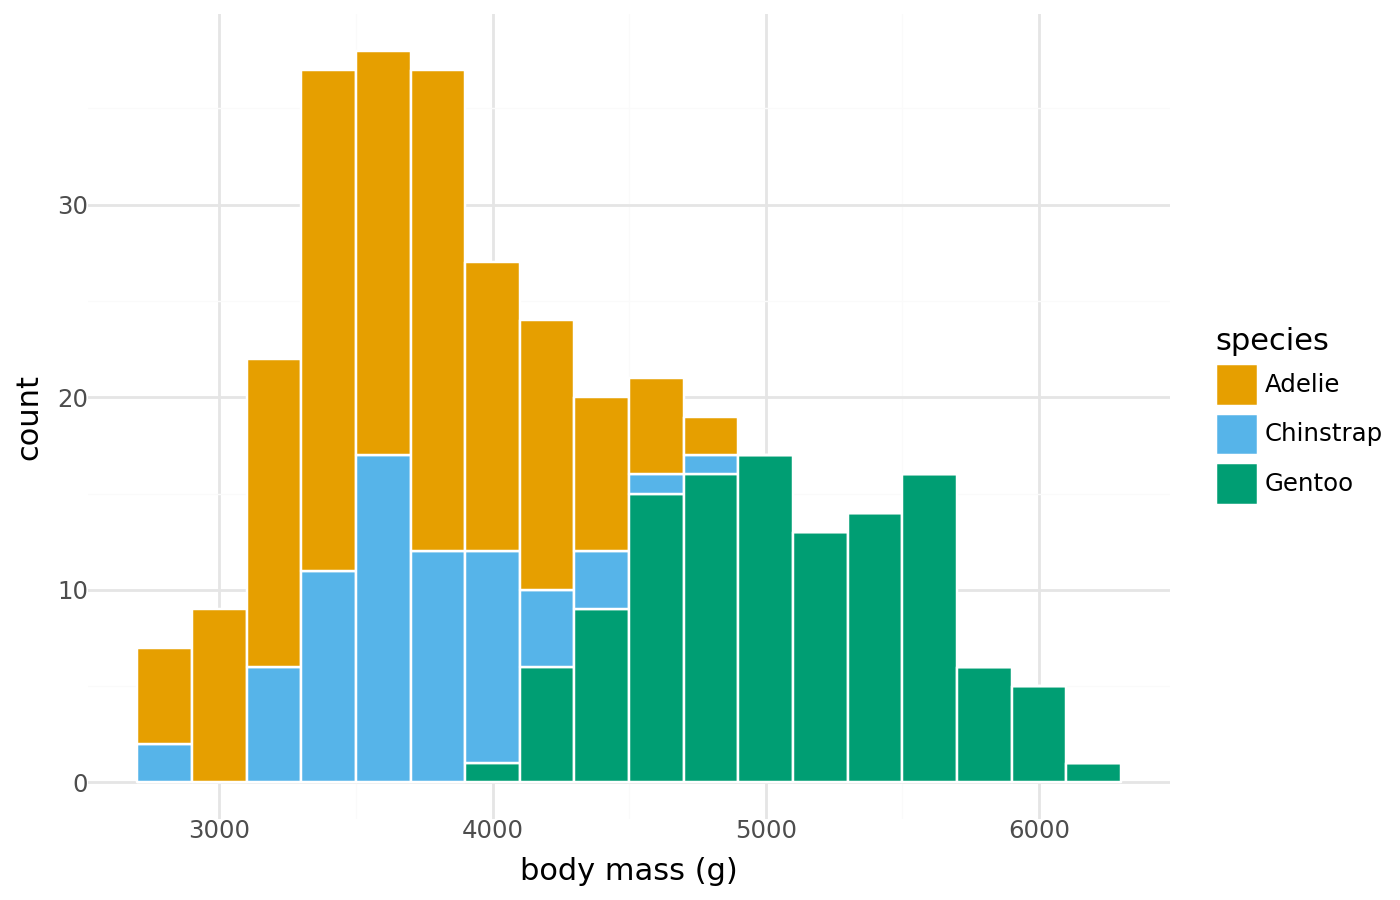

In [26]:
peng = penguins.dropna(subset=["body_mass_g", "sex"])

# ❌ 모호한 그래프 (그대로 두세요)
(
    ggplot(peng, aes(x="body_mass_g", fill="species"))
    + geom_histogram(binwidth=200, position="stack", color="white")
    + scale_fill_manual(values=OKABE_ITO)
    + labs(x="body mass (g)", y="count")
)

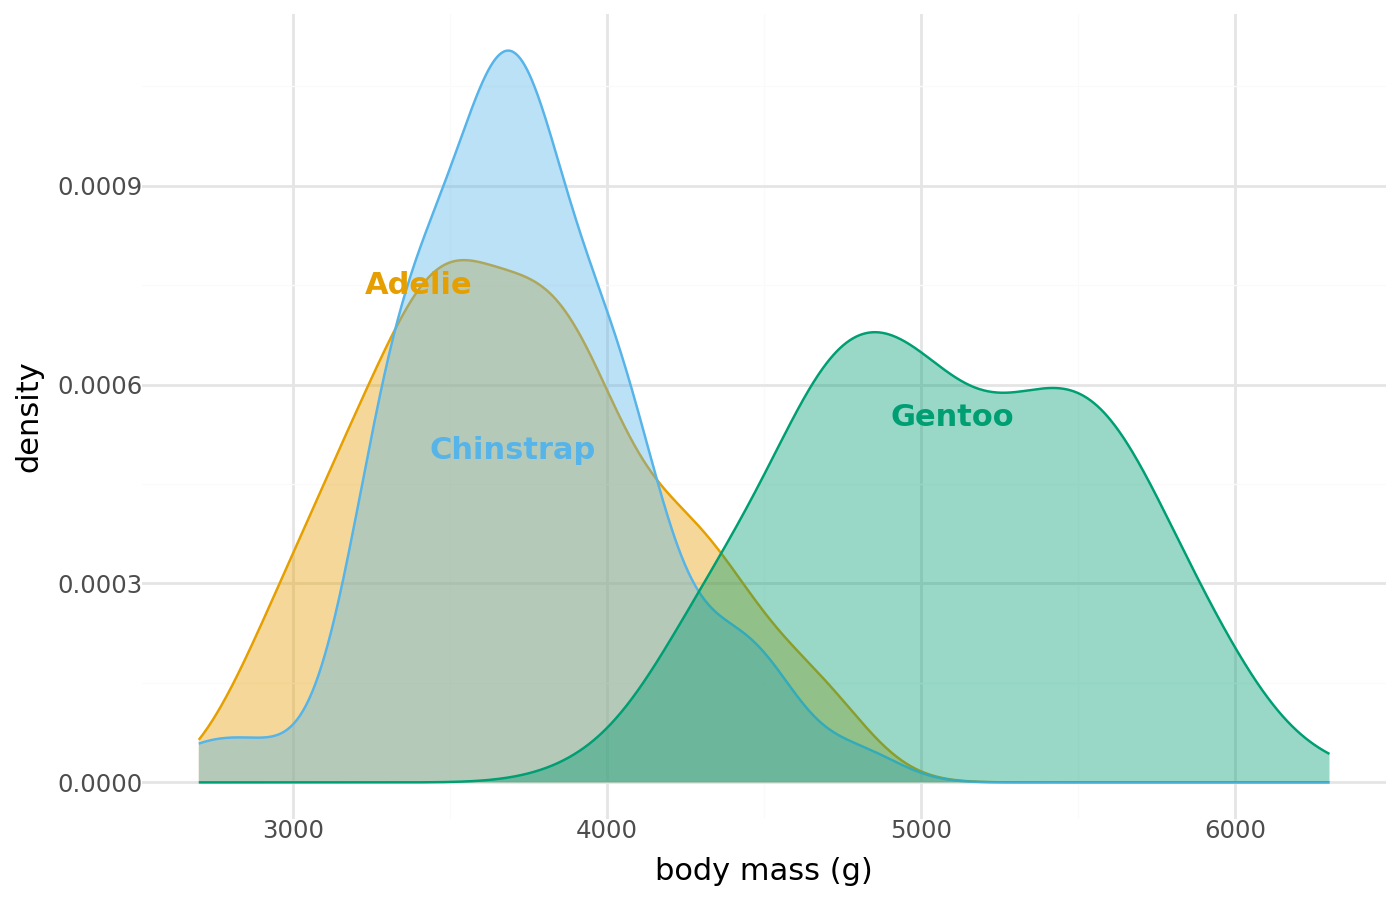

In [27]:
# ✅ 고친 그래프를 작성하세요
# 힌트: geom_density(alpha=...), 직접 라벨은 geom_text(..., data=라벨용 DataFrame)
(
    ggplot(peng, aes(x="body_mass_g", fill="species", color="species"))
    + geom_density(alpha=0.4)
    + scale_fill_manual(values=OKABE_ITO)
    + scale_color_manual(values=OKABE_ITO)
    + annotate("text", x=3400, y=0.00075, label="Adelie", color=OKABE_ITO[0], fontweight="bold")
    + annotate("text", x=3700, y=0.00050, label="Chinstrap", color=OKABE_ITO[1], fontweight="bold")
    + annotate("text", x=5100, y=0.00055, label="Gentoo", color=OKABE_ITO[2], fontweight="bold")
    + labs(x="body mass (g)", y="density")
    + theme(legend_position="none")
)

### 문제 5-5 (빈칸) — 전체 분포 대비 비중
슬라이드 49처럼 **수컷과 암컷의 날개 길이 분포**를 따로 그리되, 각 패널 뒤에 **전체 펭귄의 분포를 회색으로** 깔아서 각 성별이 전체에서 차지하는 비중을 보여 주세요.

> 💡 **핵심 아이디어**: 회색 배경 레이어에 `sex` 열이 **없는** 데이터를 주면, `facet_wrap("sex")`이 그 레이어를 모든 패널에 똑같이 그립니다.
> y축은 `after_stat("count")`로 **밀도 × 개수**를 써서, 전체 곡선 아래 면적이 전체 마릿수가 되게 합니다.

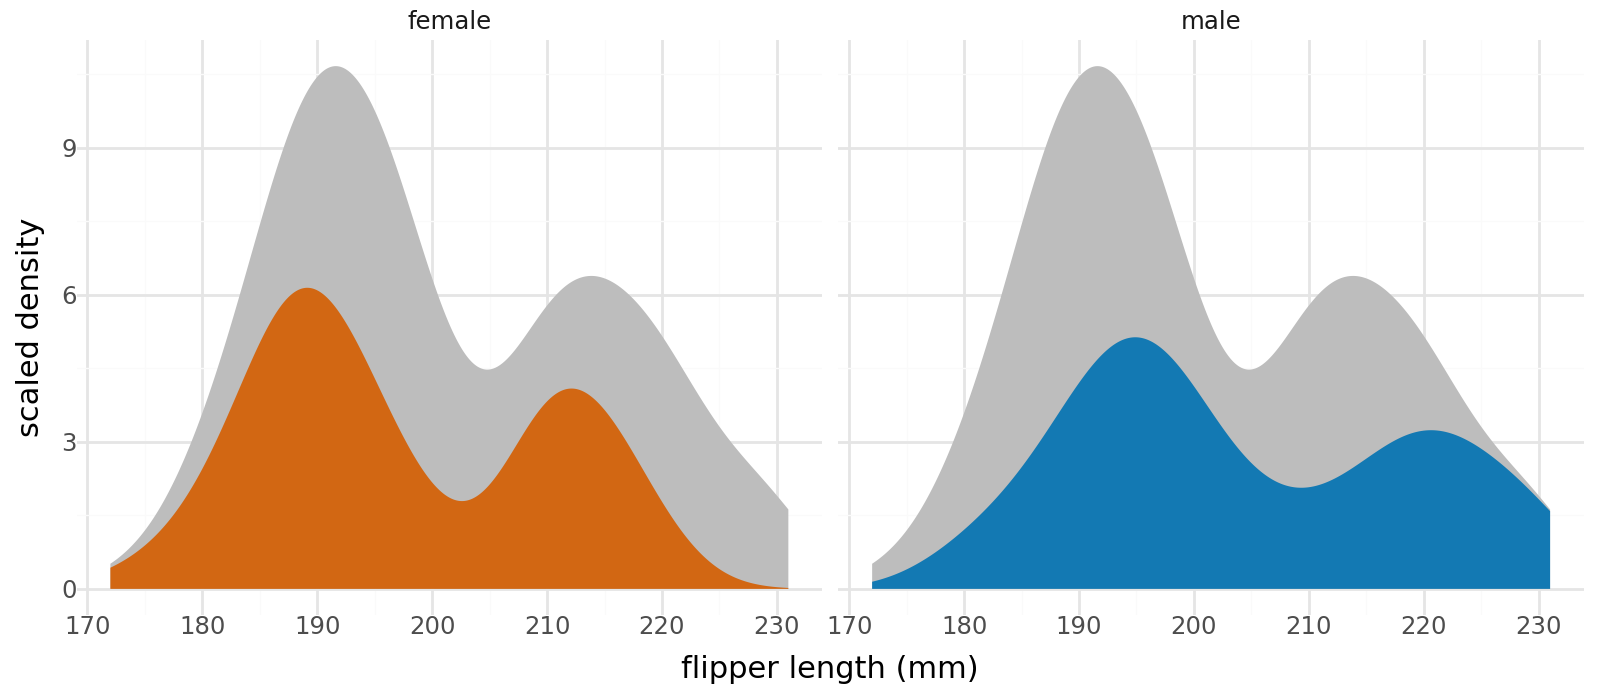

In [28]:
all_peng = peng.drop(columns="sex")    # TODO: 어떤 열을 없애야 할까요?

(
    ggplot(peng, aes(x="flipper_length_mm", y=after_stat("count")))
    + geom_density(data=all_peng, fill="#BDBDBD", color="none")        # TODO: 회색 배경 = 전체 데이터
    + geom_density(aes(fill="sex"), color="none", alpha=0.9)
    + facet_wrap("sex")                                                        # TODO: 성별로 패널 나누기
    + scale_fill_manual(values={"male": "#0072B2", "female": "#D55E00"}, guide=None)
    + labs(x="flipper length (mm)", y="scaled density")
    + theme(figure_size=(8, 3.5))
)

### 문제 5-6 (보너스) 연령 피라미드 스타일
슬라이드 50의 **연령 피라미드**처럼 수컷과 암컷의 **몸무게 히스토그램**을 좌우로 마주 보게 그려 보세요.

> 💡 힌트: 구간별 개수를 직접 세고(`pd.cut`), 한쪽 성별의 개수에 **−1을 곱한 뒤** `geom_col` + `coord_flip()`을 사용합니다.

In [ ]:
# ✏️ 보너스 문제 (선택)

## 6. 종합 문제 📝

`plotnine.data`의 데이터셋 중 **하나를 골라** 세션에서 배운 원칙을 적용한 그래프를 **1개 이상** 그리세요.
사용 가능한 데이터셋 예시: `diamonds`, `economics`, `msleep`, `mpg`, `midwest`, `penguins`, `txhousing` 등

그래프 아래에 다음 내용을 적어 주세요.
1. 어떤 질문에 답하려는 그래프인가요?
2. 데이터 종류(수량 / 분포 등)에 맞춰 **어떤 도표**를 골랐고, 그 이유는 무엇인가요?
3. **위치 스케일**(선형 / 로그 등)과 **색상 스케일**(정성적 / 순차적 / 발산형 / 강조)을 어떻게 선택했나요?
4. 세션에서 본 *ugly / bad / wrong* 사례 중 피하려고 신경 쓴 부분이 있다면 적어 주세요.

In [ ]:
# ✏️ 자유롭게 작성하세요

/tmp/ipykernel_2455/2202848480.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


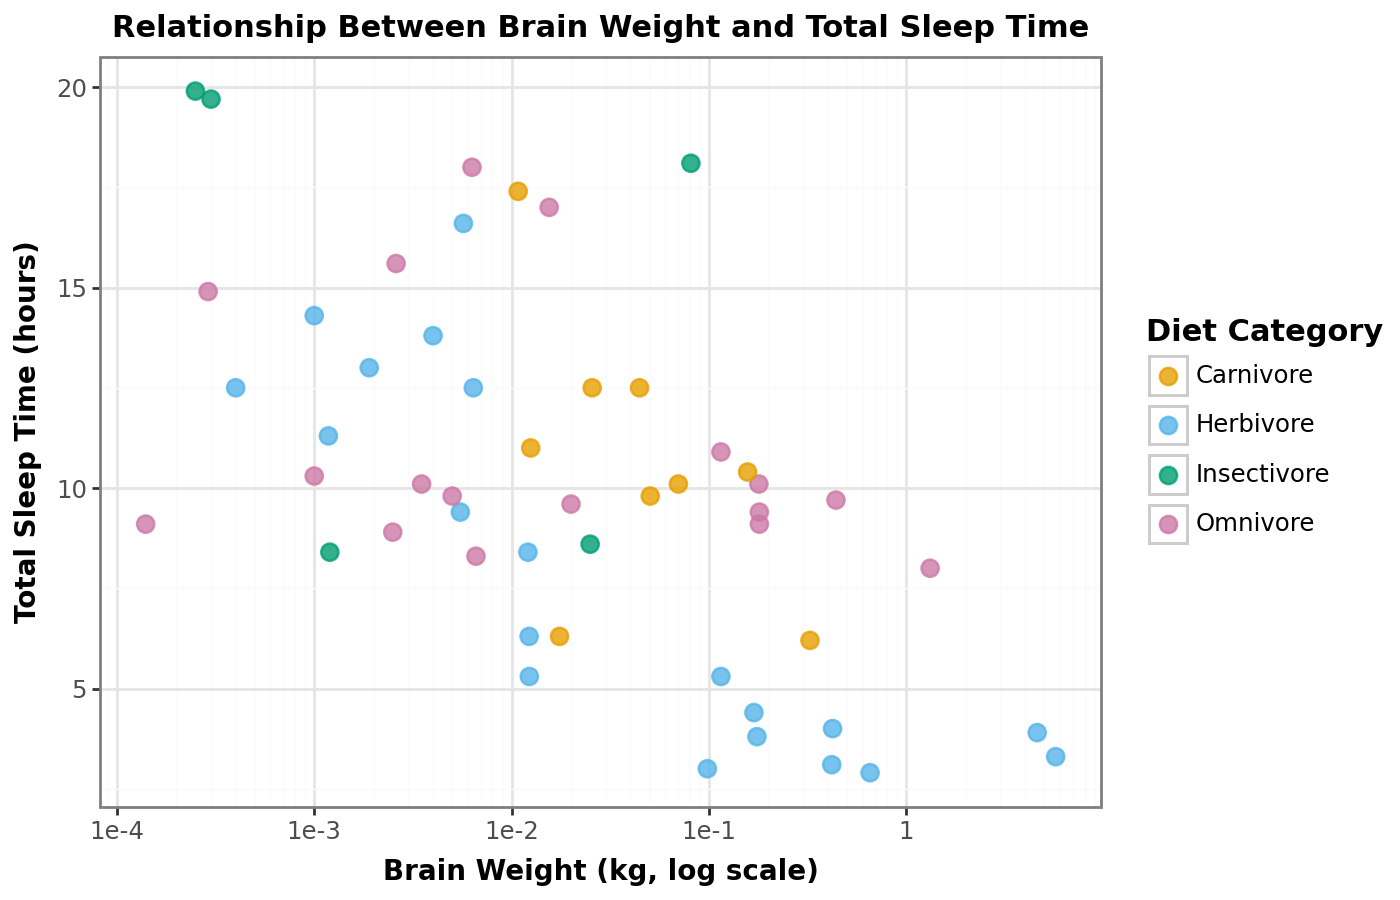

In [30]:
from plotnine import *
from plotnine.data import msleep
msleep_clean = msleep.dropna(subset=["brainwt", "sleep_total", "vore"])
vore_map = {
    "carni": "Carnivore",
    "herbi": "Herbivore",
    "omni": "Omnivore",
    "insecti": "Insectivore"
}
msleep_clean["vore_label"] = msleep_clean["vore"].map(vore_map)
OKABE_ITO_4 = ["#E69F00", "#56B4E9", "#009E73", "#CC79A7"]
(
    ggplot(msleep_clean, aes(x="brainwt", y="sleep_total", color="vore_label"))
    + geom_point(size=3, alpha=0.8)
    + scale_x_log10(name="Brain Weight (kg, log scale)")
    + scale_color_manual(values=OKABE_ITO_4, name="Diet Category")
    + labs(
        title="Relationship Between Brain Weight and Total Sleep Time",
        y="Total Sleep Time (hours)"
    )
    + theme_bw()
    + theme(
        figure_size=(7, 4.5),
        legend_position="right",
        axis_title=element_text(size=10, fontweight="bold"),
        title=element_text(size=11, fontweight="bold")
    )
)

**✍️ 답:**
1. 어떤 질문에 답하려는 그래프인가요?
- 포유류의 뇌 무게(뇌 크기)와 하루 총 수면 시간 사이에 어떠한 상관관계가 존재하는지, 그리고 식성에 따라 그 관계나 수면 양상에 차이가 나타나는지 파악하고자 했다.


2. 데이터 종류(수량 / 분포 등)에 맞춰 어떤 도표를 골랐고, 그 이유는 무엇인가요?
- 산점도를 골랐다. 뇌 무게와 수면 시간이라는 두 개의 연속형 수량 변수 간의 상관관계 및 세부 분포를 관찰하는 데 가장 적합한 시각화 방식이기 때문이다. 식성 변수는 색상 인코딩을 적용해 그룹별 차이를 한 화면에서 비교하도록 구성했다.


3. 위치 스케일(선형 / 로그 등)과 색상 스케일(정성적 / 순차적 / 발산형 / 강조)을 어떻게 선택했나요?
- x축의 뇌 무게 데이터는 생물체 크기에 따라 우편향이 매우 심하다. 선형 스케일을 사용할 경우 소형 동물이 y축 근처에 과도하게 밀집되므로, 로그 스케일을 적용하여 전체적인 관측치가 넓게 dispersion되도록 하고 비선형적 관계를 명확히 시각화했다. y축은 수면 시간의 범위가 명확하므로 일반 선형 스케일을 유지했다.
- 식성은 명목형 범주 데이터이므로 색상 간 우위나 순서가 없는 정성적 색상 스케일인 Okabe-Ito 색상 팔레트를 적용했다. 또한 색각 이상자를 고려한 고대비 색상을 선택해 가독성을 높였다.

4. 세션에서 본 ugly / bad / wrong 사례 중 피하려고 신경 쓴 부분이 있다면 적어 주세요.
- 축 라벨에 brainwt, sleep_total 같은 변수명 대신 단위를 명시한 Brain Weight (kg, log scale), Total Sleep Time (hours)을 작성하고, carni, herbi 등 약어로 되어 있던 범주명을 Carnivore, Herbivore로 정제하여 가독성을 확보했다.

## ⚙️ 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): 문법 디버깅, 연령 피라미드 축 음수 처리 변환에 사용

- **AI가 이 실험에는 틀린 답을 준 사례**
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: 월별 주택 거래량 시각화(문제 4-2)에서 AI가 명목형 범주처럼 단순히 매출 크기순(reorder(month_name, -sales))으로 정렬하는 코드를 제시했다.

- **실제 대화 내역** 붙여넣기:

```
shape에 "cyl" 대신 "factor(cyl)"을 넣어야 하는 이유는 무엇일까요? 모양이라는 시각적 속성이 표현할 수 있는 데이터 종류와 연결해서 설명하세요. 이거 알려줘

shape에 "cyl" 대신 "factor(cyl)"을 지정해야 하는 이유는 데이터 타입과 시각적 인코딩(Visual Encoding) 간의 적절성 차이 때문입니다.

1. cyl 데이터의 본질: 연속형 vs 범주형
cyl(실린더 수) 데이터는 숫자로 저장되어 있어 R/Python(plotnine)에서 기본적으로 연속형 수량 데이터(Continuous Numeric Data)로 인식됩니다.

그러나 실제 자동차 엔진에서 실린더 수는 4.2개, 5.7개처럼 연속적으로 존재하는 수치가 아니라 4기통, 6기통, 8기통처럼 몇 가지 명확한 그룹으로 나뉘는 범주형 데이터(Categorical Data)입니다.

cyl: 연속형 숫자로 처리됨 (예: 4, 6, 8)

factor(cyl): 4, 6, 8이라는 범주(Category) 또는 라벨(Factor)로 변환됨

2. '모양(Shape)'이라는 시각적 속성의 한계
시각적 인코딩 매핑에서 모양(Shape) 채널은 크기(Size)나 투명도(Alpha)와 달리 순서나 크기 비교가 불가능한 명목형 범주(Nominal Category)에만 적합합니다.

서로 다른 모양(동그라미, 세모, 네모, 크로스 등)은 단지 "서로 종류가 다르다"는 사실만 알려줄 뿐, 동그라미가 세모보다 "더 크다"거나 "2만큼 더 많다"는 양적 정보를 전달하지 못합니다.

따라서 ggplot / plotnine 엔진은 연속형 데이터를 순서나 양적 의미가 없는 shape 속성에 매핑하는 것을 거부하거나 에러/경고를 발생시킵니다.

3. 결론
factor(cyl)을 사용해 데이터 타입을 범주형(Factor/Category)으로 명시해 주어야 비로소 시각화 엔진이 "이 데이터는 연속적인 수치가 아니라 그룹 구분용 범주구나"라고 이해하고, 각 기통별 수치에 동그라미, 세모, 네모 등의 서로 다른 모양(Shape)을 차례로 할당할 수 있게 됩니다.

문제 2-2 🔧 고치기

슬라이드 11의 wrong 사례처럼, 아래 그래프는 데이터와 축 제목이 맞지 않습니다. 무엇이 잘못됐는지 찾고, 원본 데이터를 로그 스케일로 올바르게 그리도록 고치세요.# ❌ 잘못된 그래프 (그대로 두세요)

county["log_ratio"] = np.log10(county["ratio"])



(

    ggplot(county, aes(x="rank", y="log_ratio"))

    + geom_point(size=0.8, color="#0072B2")

    + labs(x="Midwest counties, from most to least populous", y="population / median")

) 잘못못된 부분 모르겟어

잘못된 부분의 핵심은 데이터를 직접 변환(Data Transformation)한 것과 축 스케일 변환(Scale Transformation)을 혼동하여, y축의 눈금(Tick mark) 수치와 축 라벨(y-axis title)이 서로 일치하지 않게 되었다는 점입니다.

1. 무엇이 잘못되었나요?
데이터 직접 변환의 문제: county["log_ratio"] = np.log10(county["ratio"])처럼 데이터 프레임 자체의 값을 log
10
​
  단위(예: 0,1,2)로 변환한 뒤 y축에 연결했습니다.

축 라벨과의 불일치: 데이터 값은 이미 로그가 취해진 값(0,1,2)인데, 축 라벨에는 y="population / median"으로 원래 단위(비율 수치)인 것처럼 적혀 있습니다. 관찰자는 축 눈금의 1을 보고 "비율이 1이구나"라고 오인하지만, 실제 데이터는 10
1
 =10을 의미하므로 시각적 왜곡(Visual Distortion / Wrong Labeling)이 발생합니다.

올바른 방식: 데이터 프레임의 원본 값(ratio)은 그대로 두고, 시각화 표현 단계에서 scale_y_log10()을 사용해 축 스케일만 로그로 변경해야 눈금 라벨이 원래 수치(10,100 등)로 올바르게 표시됩니다.

2. 올바르게 고친 그래프 코드
원본 데이터 ratio를 그대로 사용하고 scale_y_log10()을 적용하여 고친 코드입니다.

Python
# ⭕ 고친 그래프
(
    ggplot(county, aes(x="rank", y="ratio"))
    + geom_point(size=0.8, color="#0072B2")
    + scale_y_log10()
    + labs(
        x="Midwest counties, from most to least populous",
        y="population / median"
    )
)
요약
y="ratio": 원본 수치를 그대로 매핑합니다.

scale_y_log10(): 축 스케일만 로그 변환하여, y축 눈금에 원본 데이터 단위의 실제 수치가 올바르게 표기되도록 합니다.

3-3에는 순차적 스케일을, 3-4에는 발산형 스케일을 쓴 이유를 설명하세요 이 질문에서 연속형 변수, 양방향 변수여서 그런거 맞나
맞습니다! 핵심을 아주 정확하게 짚으셨습니다.

데이터 변수가 일방향 연속형 변수(Unidirectional Continuous Variable)인지, 중심점(Reference Point)을 기준으로 양방향 변수(Bidirectional Variable)인지에 따른 차이 때문입니다.

구체적으로 서술형 문제에 맞춰 정리해 드리면 다음과 같습니다.

1. 3-3에서 순차적 스케일(Sequential Scale)을 사용한 이유
데이터의 특성: 해당 변수(예: 인구수, 주택 가격 등)는 0 이상의 최소값부터 시작해 한쪽 방향으로만 증가하는 일방향 연속형 변수(Unidirectional Continuous Variable)입니다.

시각적 인코딩: 값이 작음에서 큼(낮음에서 높음)으로 단조 증가하는 흐름을 보여주는 것이 목적이므로, 단일 색상의 명도(Lightness)나 채도(Saturation) 변화를 이용해 '작다/크다'의 양적 크기를 직관적으로 나타내는 순차적 스케일이 적합합니다.

2. 3-4에서 발산형 스케일(Diverging Scale)을 사용한 이유
데이터의 특성: 해당 변수(예: 인구 증가율/감소율, 평균 대비 편차, 중위수 대비 비율 등)는 특정 기준점(Reference Point/Baseline, 예: 0, 100%, 평균값)을 중심으로 양쪽으로 갈라지는 양방향 변수(Bidirectional Variable)입니다.

시각적 인코딩: 기준점(예: 중립적 색상인 회색/흰색)을 사이에 두고 서로 대비되는 두 가지 색상(예: 파란색 vs 주황색)을 사용함으로써, 어느 방향으로 얼마나 치우쳐 있는지(양수/음수, 높은 쪽/낮은 쪽)를 한눈에 식별하게 해주는 발산형 스케일이 적합합니다.

✍️ 한 줄 요약 정리

3-3은 한쪽 방향으로만 크기가 증가하는 일방향 연속형 변수이므로 순차적 스케일을 적용했고, 3-4는 기준점을 중심으로 양쪽(양/음, 높음/낮음)으로 갈라지는 양방향 변수이므로 발산형 스케일을 적용한 것입니다.막대도표에서는 y축을 0이 아닌 곳에서 시작하면 안 되는데, 점 도표에서는 괜찮은 이유는 무엇일까요 이유 자세히 설명해줘 명확히 말을 못하겠어

막대도표와 점 도표에서 'y축의 0 포함 여부'가 다른 이유는, 데이터를 visual로 변환할 때 사용자가 판단 기준으로 사용하는 시각적 채널(Visual Channel)이 서로 다르기 때문입니다.

직관적으로 이해하기 쉽게 2가지 핵심 차이로 나누어 설명해 드릴게요.

1. 막대도표: '면적과 길이의 비율'로 데이터를 인식함
작동 원리: 막대도표에서 데이터의 크기는 막대의 '길이(Length)'와 '면적(Area)'으로 인코딩됩니다.

0이 없으면 발생하는 문제:
예를 들어 매출이 100과 105인 두 회사가 있을 때, y축을 100부터 시작하여 막대를 그리면:

100짜리 막대의 높이는 0에 가깝게 보이고,

105짜리 막대는 높이가 꽤 높게 보입니다.

이 경우 관찰자의 뇌는 "B 회사가 A 회사보다 매출이 몇 배나 크구나!"라고 시각적 착시(Visual Distortion)를 느끼게 됩니다. 막대의 '길이 비율'이 실제 데이터의 '수치 비율'과 깨져버리기 때문에 막대도표는 반드시 y축이 0부터 시작해야만 왜곡이 발생하지 않습니다.

2. 점 도표(Cleveland Dot Plot): '위치와 거리'로 데이터를 인식함
작동 원리: 점 도표는 면적을 차지하지 않는 '점의 위치(Position)'와 점들 간의 '상대적 거리(Distance)'로 데이터를 인코딩합니다.

0이 없어도 괜찮은 이유:

점 도표를 볼 때 사람의 눈은 "0에서부터 점까지의 길이"를 보는 것이 아니라, "점들이 축 상의 어느 위치에 있는가"와 "점과 점 사이의 간격이 얼마나 떨어져 있는가"를 관찰합니다.

막대처럼 바닥에서부터 채워진 면적이 없기 때문에, '길이의 비율'을 비교하려는 시각적 본능이 작동하지 않습니다.

따라서 y축(또는 x축)을 0이 아닌 데이터의 최솟값 근처(예: 90∼110)로 축소하여 보여주더라도, "두 점 사이의 차이(Absolute/Relative Distance)"만 명확하게 확대하여 보여줄 뿐 수치를 왜곡하지 않습니다.

💡 한 줄 요약 (답안 작성용)
"막대도표는 막대의 '길이와 면적의 비율'로 수량을 표현하므로 비율 왜곡을 막기 위해 0부터 시작해야 하지만, 점 도표는 점의 '상대적 위치'만으로 수치를 표현하므로 축을 0부터 시작하지 않고 범위를 축소해도 시각적 왜곡이 발생하지 않습니다."
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은 무엇이었나요? 시각화 라이브러리의 기계적 코드 생성을 넘어, 데이터의 본질적 특성(시간의 순서성 vs 크기의 우위)과 시각적 인지 원칙(베이스라인 왜곡 방지 및 눈금 직관성)을 고려하여 관찰자에게 왜곡 없는 맥락을 전달하도록 시각화의 목적을 직접 정의하고 통제한 것은 나만의 판단이다.

---
### 수고하셨습니다! 🎉
제출 전 **런타임 → 모두 실행**으로 모든 셀이 에러 없이 실행되는지 확인해 주세요.